# Calibração conformal temporal e intervalos preditivos

Neste notebook, a camada de incerteza é calibrada sobre as previsões OOF de desenvolvimento já congeladas. O Champion pontual E0 é preservado, nenhum estimator é reajustado e o holdout final não é reaberto.

Como a execução inicial é realizada em modo smoke, a infraestrutura é validada sem que um ranking definitivo seja produzido.


In [1]:
import os
import sys
import warnings

sys.path.insert(0, os.path.abspath('..'))

from matplotlib import pyplot as plt

from src import conformal_uncertainty_reports as reports
from src.conformal_uncertainty import (
    ConformalUncertaintyConfig,
    conformal_method_specs,
    run_conformal_uncertainty_experiments,
)
from src.i18n import make_lang
from src.plotting import set_graph_parameters

warnings.filterwarnings('ignore', category=FutureWarning)
set_graph_parameters()
plt.rcParams['axes.grid'] = False
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

lang = make_lang('pt')


## 1. Objetivo e fronteiras experimentais

Foi investigado se os erros históricos do E0 podem ser convertidos em intervalos empiricamente calibrados sem modificar sua previsão central. A comparação foi restrita à camada de incerteza e nenhuma conclusão confirmatória foi autorizada por esta etapa.

O CQR de Romano, Patterson e Candès (2019) foi mantido como hipótese futura, pois sua inclusão exigiria novos modelos quantílicos e ultrapassaria o escopo pós-modelo deste notebook.


In [2]:
reports.environment_report(lang=lang)


,Item,Valor
0,Ambiente conda,Bike-Sharing
1,Interpretador (sys.executable),CONDA_PREFIX\py...
2,Versão do Python,3.10.20
3,Fingerprint do ambiente,8f80d9216d47a792
4,Divergências em relação ao environment.yml,nenhuma
5,Requisitos declarados no modelo,"mlflow==2.10.0, cloudpickle==3.1.2, numpy==1.2..."
6,scikit-learn,1.3.2
7,pandas,2.2.3
8,numpy,1.26.4
9,mlflow,2.10.0


## 2. Ambiente e artefatos congelados

O ambiente `Bike-Sharing` é exigido antes da execução. O manifesto e as previsões OOF produzidos pelo Notebook 06 são tratados como entradas congeladas, e seus fingerprints e hashes são auditados antes da calibração.

O acesso ao holdout permanece vedado. Somente os pontos do E0 e a escala experimental do E4 são alinhados por fold, ano meteorológico e timestamp.


In [3]:
config = ConformalUncertaintyConfig(run_mode='full')
display(reports.protocol_report(config, lang=lang))


,Item,Valor
0,Modo de execução,full
1,Natureza da conclusão,candidato experimental para a camada de incerteza
2,Uso do holdout final,não utilizado
3,Fonte das previsões,previsões OOF congeladas do Notebook 06
4,Centro dos intervalos,E0
5,Warm-up por fold,168 horas
6,Reinicialização do estado,a cada fold e mudança de regime
7,Coberturas avaliadas,"80%, 90%, 95%"
8,Política para 2020,"relatório separado, fora do ranking"
9,Bootstrap temporal,500 repetições; blocos de 168 horas


## 3. Contrato prequential e prevenção de leakage

Em cada fold, as primeiras 168 horas são reservadas ao warm-up da camada de incerteza. A previsão pontual continua disponível nesse período, mas nenhum intervalo conformal é fabricado ou pontuado.

Para a hora `t`, somente escores com timestamp anterior são usados. Depois que `y_t` é observado, o estado é atualizado exclusivamente para `t+1`. O estado é reiniciado em cada fold e na mudança de regime, impedindo que 2020 alimente os anos posteriores.


## 4. Especificação dos calibradores

Os métodos U0–U5 são pré-registrados. São comparados um baseline expansível simétrico, uma versão rolling assimétrica, ponderações por recência, normalização pela escala do E4, ACI por observação e calibração hierárquica por regime.

Como a exchangeability é enfraquecida pela dependência temporal, os resultados são lidos como diagnóstico empírico. A ponderação por recência é motivada pela extensão além da exchangeability discutida por Barber et al. (2023), enquanto a atualização adaptativa segue Gibbs e Candès (2021).


In [4]:
reports.method_spec_report(conformal_method_specs(config), lang=lang)


,Candidato,Método,Especificação,Janela de calibração,Não conformidade,Alpha adaptativo,Usa escala E4,Status,Notas
0,U0,U0,Conformal expansível simétrico,expanding_within_fold,absolute_residual,False,False,planned,
1,U1,U1,Conformal rolling assimétrico,rolling_2160h,signed_residual,False,False,planned,
2,U2_h168,U2,"Conformal ponderado por recência, meia-vida 168h",rolling_2160h,recency_weighted_absolute_residual,False,False,planned,half_life_hours=168
3,U2_h720,U2,"Conformal ponderado por recência, meia-vida 720h",rolling_2160h,recency_weighted_absolute_residual,False,False,planned,half_life_hours=720
4,U2_h2160,U2,"Conformal ponderado por recência, meia-vida 2160h",rolling_2160h,recency_weighted_absolute_residual,False,False,planned,half_life_hours=2160
5,U3,U3,Conformal normalizado pela escala E4,rolling_2160h,absolute_residual_over_e4_scale,False,True,planned,
6,U4a_g0p001,U4a,"ACI sobre o erro absoluto, gamma=0.001",rolling_2160h,adaptive_absolute_residual,True,False,planned,gamma=0.001
7,U4b_g0p001,U4b,"ACI normalizado pela escala E4, gamma=0.001",rolling_2160h,adaptive_normalized_residual,True,True,planned,gamma=0.001
8,U4a_g0p005,U4a,"ACI sobre o erro absoluto, gamma=0.005",rolling_2160h,adaptive_absolute_residual,True,False,planned,gamma=0.005
9,U4b_g0p005,U4b,"ACI normalizado pela escala E4, gamma=0.005",rolling_2160h,adaptive_normalized_residual,True,True,planned,gamma=0.005


## 5. Execução e proveniência

Uma única chamada aplica os calibradores às previsões congeladas. Nenhuma chamada de treinamento ou predição de estimator é realizada, e os artefatos de origem são lidos com colunas restritas.


In [5]:
results = run_conformal_uncertainty_experiments(config)
display(reports.source_provenance_report(results, lang=lang))
reports.input_audit_report(results, lang=lang)

,Item,Valor
0,Versão do código de origem,uncertainty_experiments_v1
1,Modo do artefato de origem,full
2,Fingerprint do dataset,24f188a95febd94d
3,Fingerprint do regime,1043b392ad5e2806
4,Validação temporal de origem,ForwardMeteorologicalYearSplit_v3_normal_opera...


,Artefato,Caminho,Bytes,SHA-256
0,source_manifest,PROJECT_ROOT/...,8853,be919c91fa8a4cc77f547289f1188889c2936dcc2ef32c...
1,source_predictions,PROJECT_ROOT/...,89568037,8c074fecdff256173b3010443c7f3b217522f51a7cf74b...


## 6. Warm-up e disponibilidade operacional

A disponibilidade dos intervalos é auditada por fold e candidato. O período de warm-up é excluído das métricas, de modo que ausência de histórico não seja confundida com cobertura igual a zero.


In [6]:
reports.warmup_report(results, lang=lang)


,Candidato,Cobertura nominal,Fold,Ano meteorológico,Papel do fold,Observações totais,Observações em warm-up,Observações pontuadas,Histórico máximo
0,U0,0.80,1,2019,selection,8715,168,8547,8714
1,U0,0.90,1,2019,selection,8715,168,8547,8714
2,U0,0.95,1,2019,selection,8715,168,8547,8714
3,U0,0.80,2,2020,stress,8759,168,8591,8758
4,U0,0.90,2,2020,stress,8759,168,8591,8758
...,...,...,...,...,...,...,...,...,...
190,U5,0.90,4,2022,selection,8759,168,8591,2160
191,U5,0.95,4,2022,selection,8759,168,8591,2160
192,U5,0.80,5,2023,selection,8760,168,8592,2160
193,U5,0.90,5,2023,selection,8760,168,8592,2160


## 7. Baseline conformal expansível — U0

No U0, o quantil corrigido dos erros absolutos anteriores é expandido dentro de cada fold. Assim, inclusive 2019 passa a ser calibrável depois das primeiras 168 horas, sem que resíduos futuros sejam usados.


## 8. Assimetria temporal — U1

No U1, os quantis inferior e superior dos resíduos assinados são estimados separadamente em uma janela rolling de 2.160 horas. A limitação inferior da demanda em zero é preservada, e as violações de cada cauda são reportadas separadamente.


## 9. Ponderação por recência — U2

No U2, pesos exponenciais são aplicados ao histórico anterior, com meias-vidas de 168, 720 e 2.160 horas. Todas as variantes são exibidas, evitando que uma configuração seja escolhida silenciosamente a partir dos mesmos resultados.


In [7]:
reports.sensitivity_report(results, 'U2', lang=lang)


,Variante,Cobertura observada,Erro de cobertura,Largura média,Winkler score
20,U2_h168,0.894270,-0.005730,3239.474294,5021.881360
22,U2_h720,0.878209,-0.021791,3099.351328,5240.044560
23,U2_h2160,0.867621,-0.032379,3020.891215,5369.323632


## 10. Escala probabilística do E4 — U3

No U3, o ponto do E0 é mantido e apenas a largura é normalizada por `predicted_scale` do E4. A correlação de Spearman e o erro por decil são examinados antes que essa escala seja interpretada como informação local de risco.

Valores de escala inválidos são tratados por fallback explícito para o erro absoluto. Nenhum preenchimento silencioso é aplicado.


,Escopo,Decil da escala,Observações,Escala média prevista,Erro absoluto médio E0,Correlação de Spearman,Taxa de crescimento monotônico
0,overall,1,3500,0.250364,1008.144269,-0.135017,0.222222
1,overall,2,3499,0.250698,877.939694,-0.135017,0.222222
2,overall,3,3499,0.251044,771.640972,-0.135017,0.222222
3,overall,4,3500,0.251539,699.310803,-0.135017,0.222222
4,overall,5,3499,0.252541,680.906166,-0.135017,0.222222
5,overall,6,3499,0.259857,889.466403,-0.135017,0.222222
6,overall,7,3500,0.321573,1342.967360,-0.135017,0.222222
7,overall,8,3499,0.878711,907.648288,-0.135017,0.222222
8,overall,9,3499,1.006217,507.747493,-0.135017,0.222222
9,overall,10,3500,1.051949,504.392748,-0.135017,0.222222


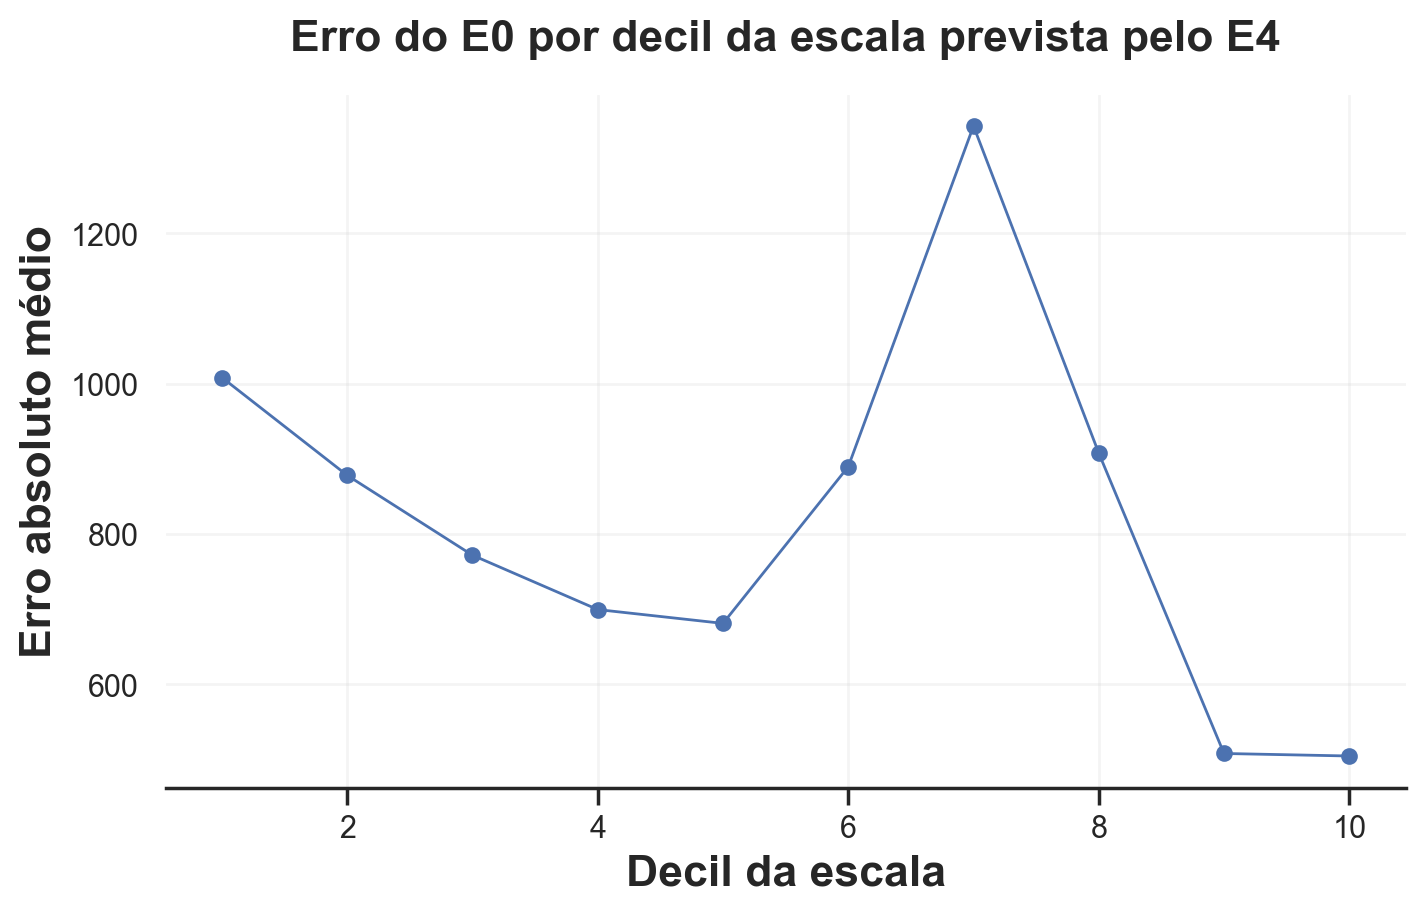

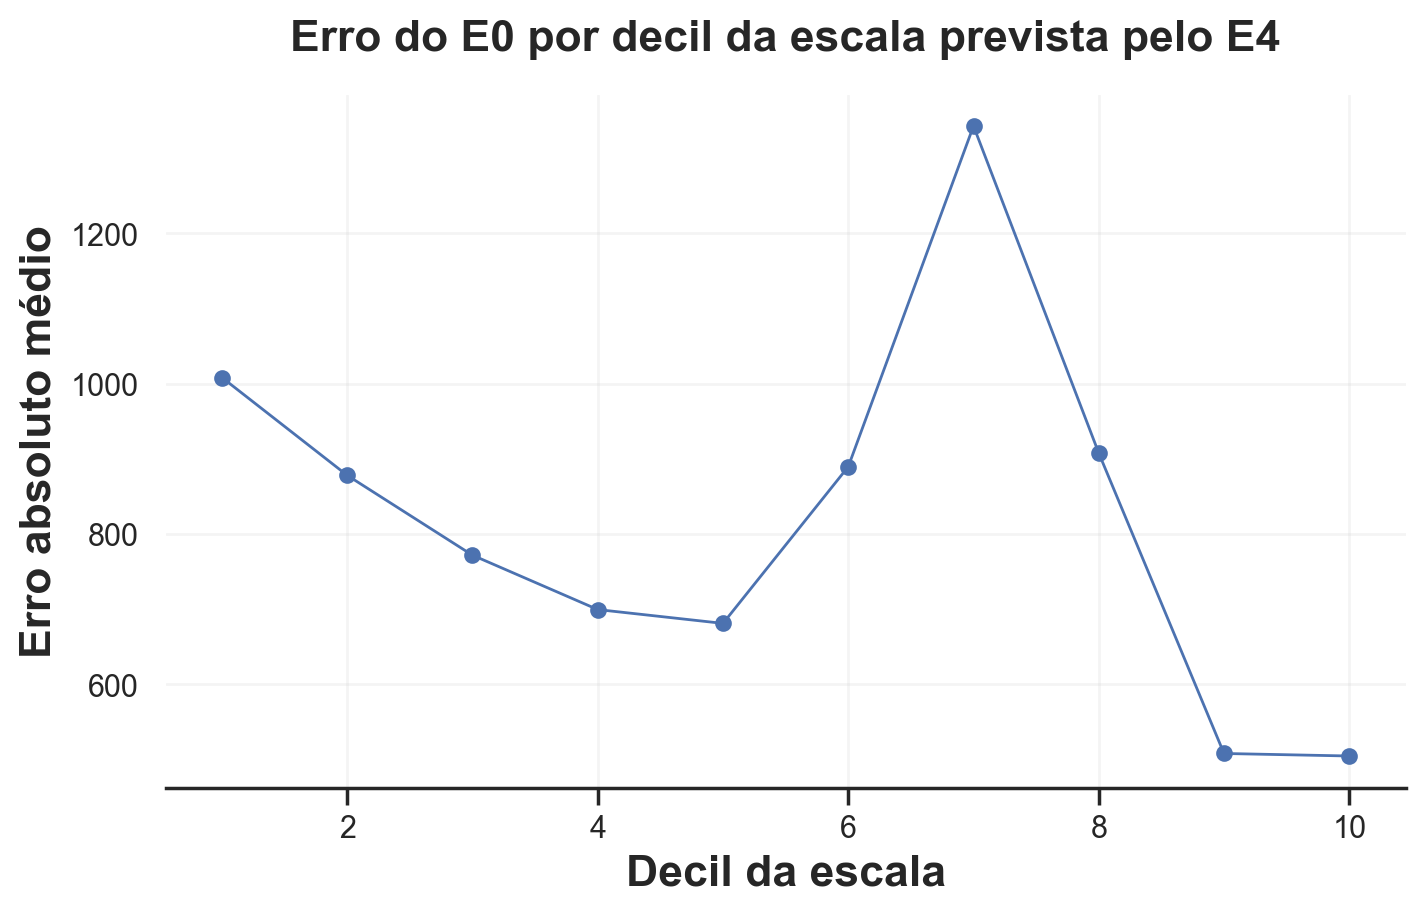

In [8]:
display(reports.scale_diagnostics_report(results, lang=lang))
reports.plot_scale_diagnostics(results, lang=lang)

## 11. Adaptive Conformal Inference — U4

No U4, `alpha_t` é atualizado depois de cada observação pontuada. Quando uma violação ocorre, o alpha é reduzido e o intervalo seguinte é ampliado; quando há cobertura, o ajuste ocorre gradualmente na direção oposta.

São comparadas versões baseadas no erro absoluto e no erro normalizado pelo E4, sob passos de 0,001, 0,005 e 0,01, conforme a lógica de Gibbs e Candès (2021).


,Variante,Cobertura observada,Erro de cobertura,Largura média,Winkler score
16,U4a_g0p01,0.901659,0.001659,3334.975219,4895.725881
18,U4a_g0p005,0.902775,0.002775,3363.234155,4956.182449
21,U4a_g0p001,0.902059,0.002059,3445.978002,5088.844671


,Variante,Cobertura observada,Erro de cobertura,Largura média,Winkler score
14,U4b_g0p01,0.901460,0.001460,3351.031061,4836.901802
17,U4b_g0p005,0.902725,0.002725,3383.733688,4901.799832
19,U4b_g0p001,0.902758,0.002758,3500.802718,5021.338938


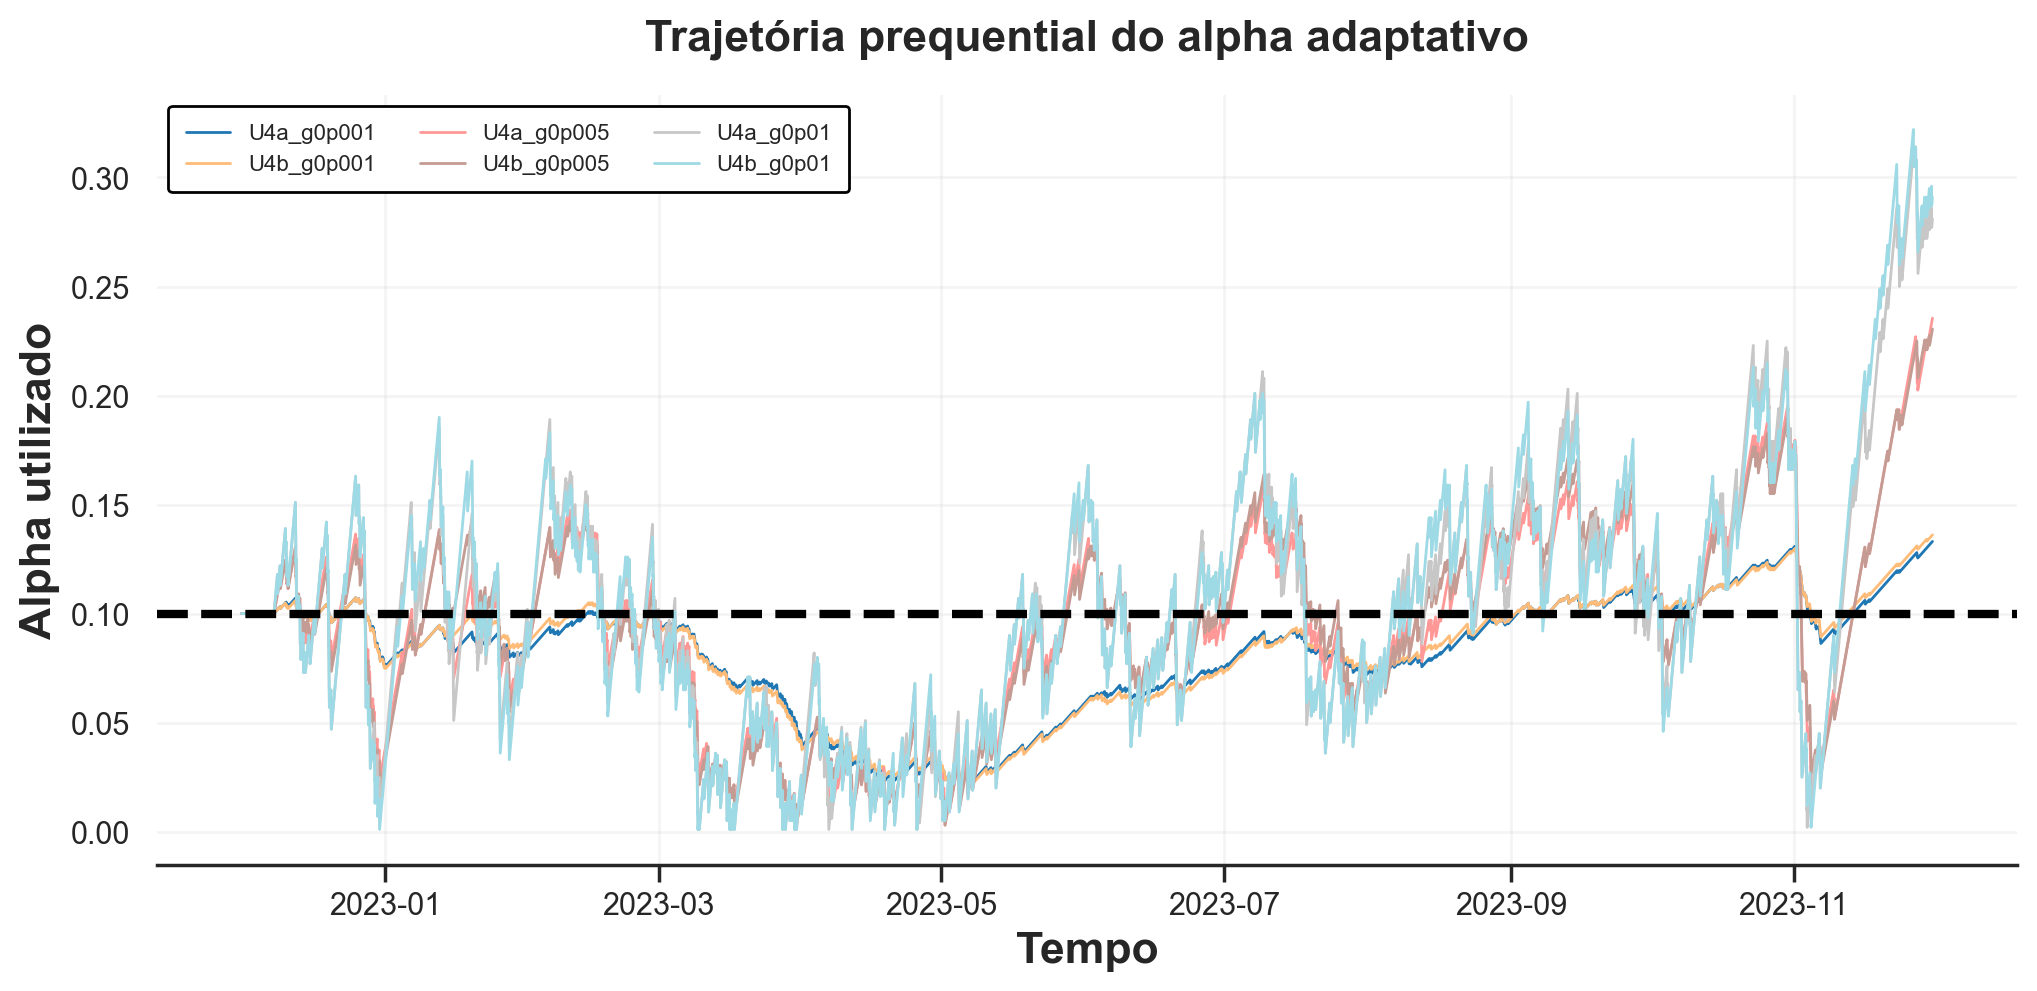

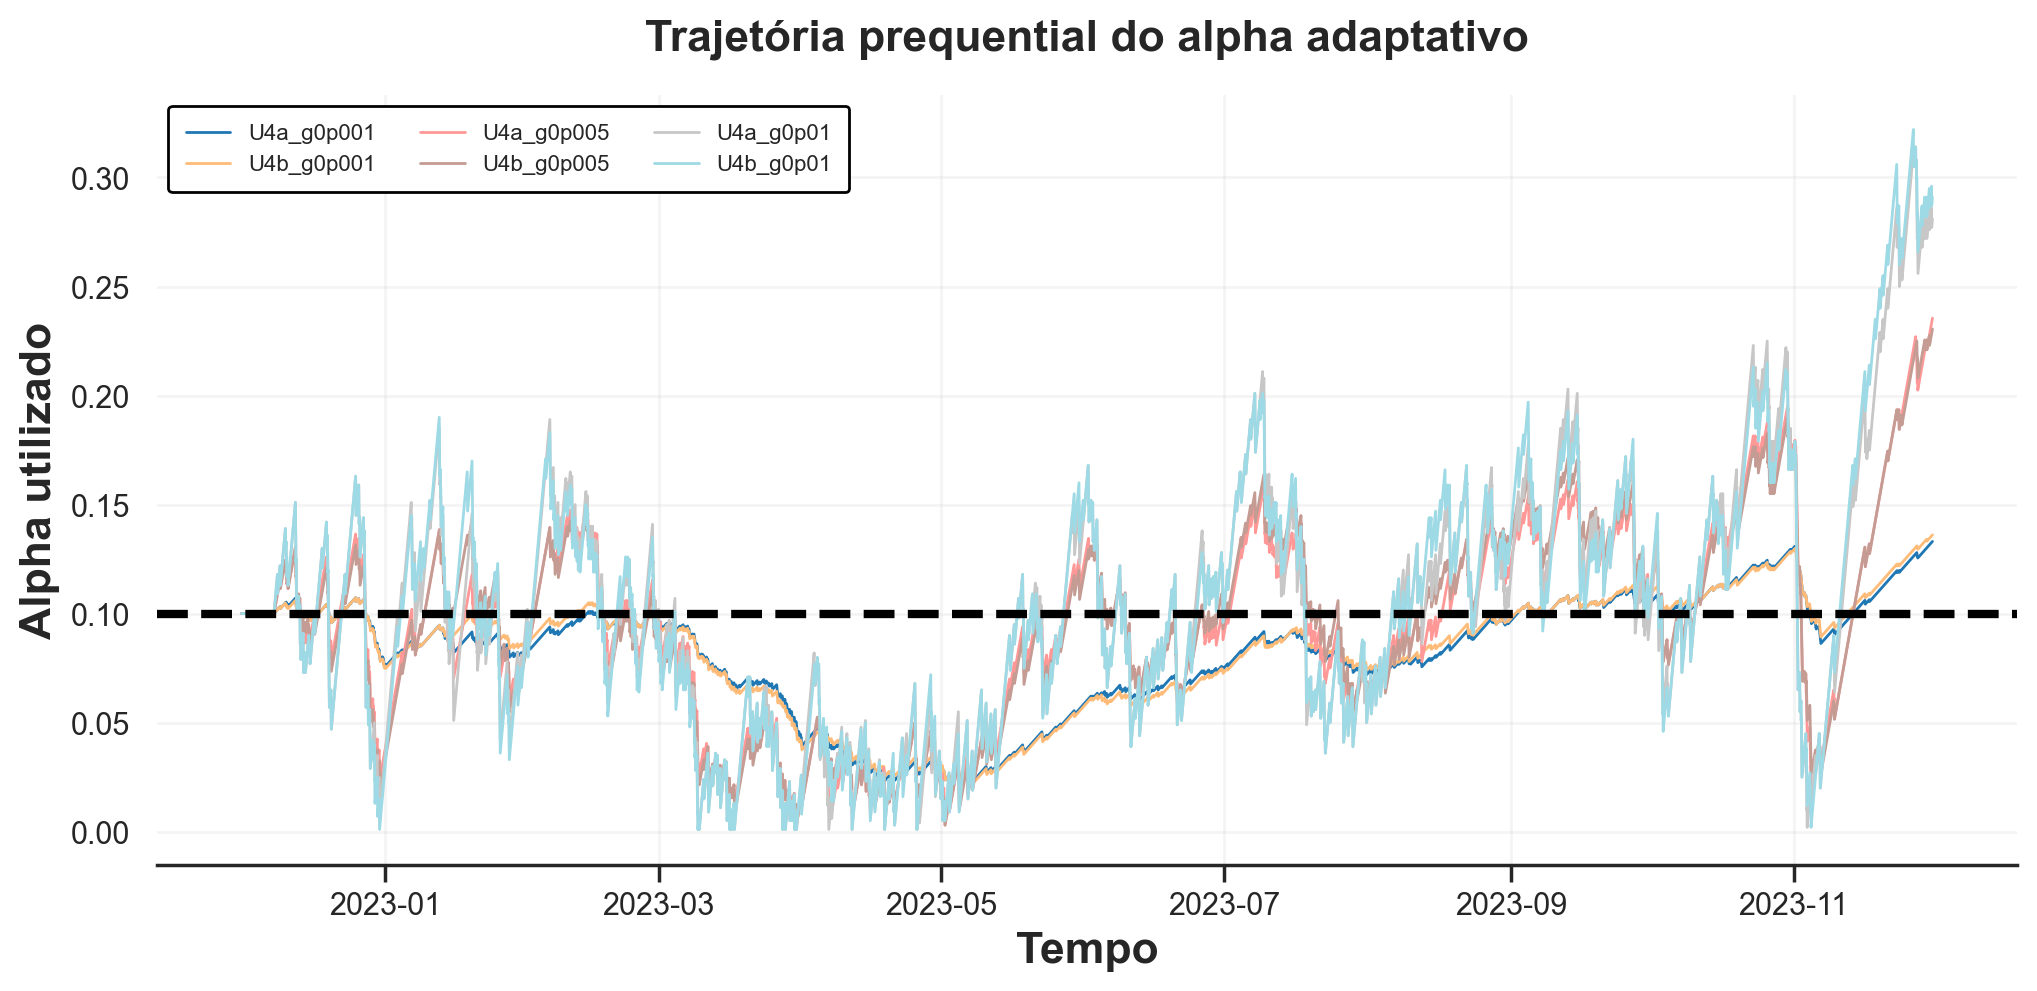

In [9]:
display(reports.sensitivity_report(results, 'U4a', lang=lang))
display(reports.sensitivity_report(results, 'U4b', lang=lang))
reports.plot_aci_alpha_trajectory(results, lang=lang)


## 12. Calibração hierárquica por regime — U5

No U5, resíduos assinados são recuperados pela hierarquia `Rush_Period × Rainfall Cat × Seasons`, seguida por níveis progressivamente mais amplos. O fallback é registrado quando o grupo específico ainda não possui histórico suficiente.

Somente variáveis conhecidas no momento da previsão são empregadas na calibração. As faixas de demanda prevista são usadas apenas na auditoria dos resultados.


,Candidato,Tipo de segmento,Segmento,Observações,Cobertura observada,Erro de cobertura,Largura média,Winkler score,Taxa de fallback,Alerta de subcobertura
0,U0,Rush_Period,Evening Rush,3884,0.529609,-0.370391,2535.372819,13656.124286,0.000000,True
1,U0,Rush_Period,Morning Rush,2916,0.608368,-0.291632,2522.549060,11718.478684,0.000000,True
3,U1,Rush_Period,Evening Rush,3884,0.674047,-0.225953,2640.854314,8682.689354,0.000000,True
4,U1,Rush_Period,Morning Rush,2916,0.737654,-0.162346,2633.431640,7885.576773,0.000000,True
6,U2_h168,Rush_Period,Evening Rush,3884,0.666581,-0.233419,3407.582560,9150.000902,0.000000,True
7,U2_h168,Rush_Period,Morning Rush,2916,0.748971,-0.151029,3349.393991,8201.840190,0.000000,True
9,U2_h2160,Rush_Period,Evening Rush,3884,0.622812,-0.277188,3179.490713,10647.151375,0.000000,True
10,U2_h2160,Rush_Period,Morning Rush,2916,0.712620,-0.187380,3143.909247,9310.568018,0.000000,True
12,U2_h720,Rush_Period,Evening Rush,3884,0.641864,-0.258136,3262.840943,10111.403167,0.000000,True
13,U2_h720,Rush_Period,Morning Rush,2916,0.727366,-0.172634,3221.962700,8900.479094,0.000000,True


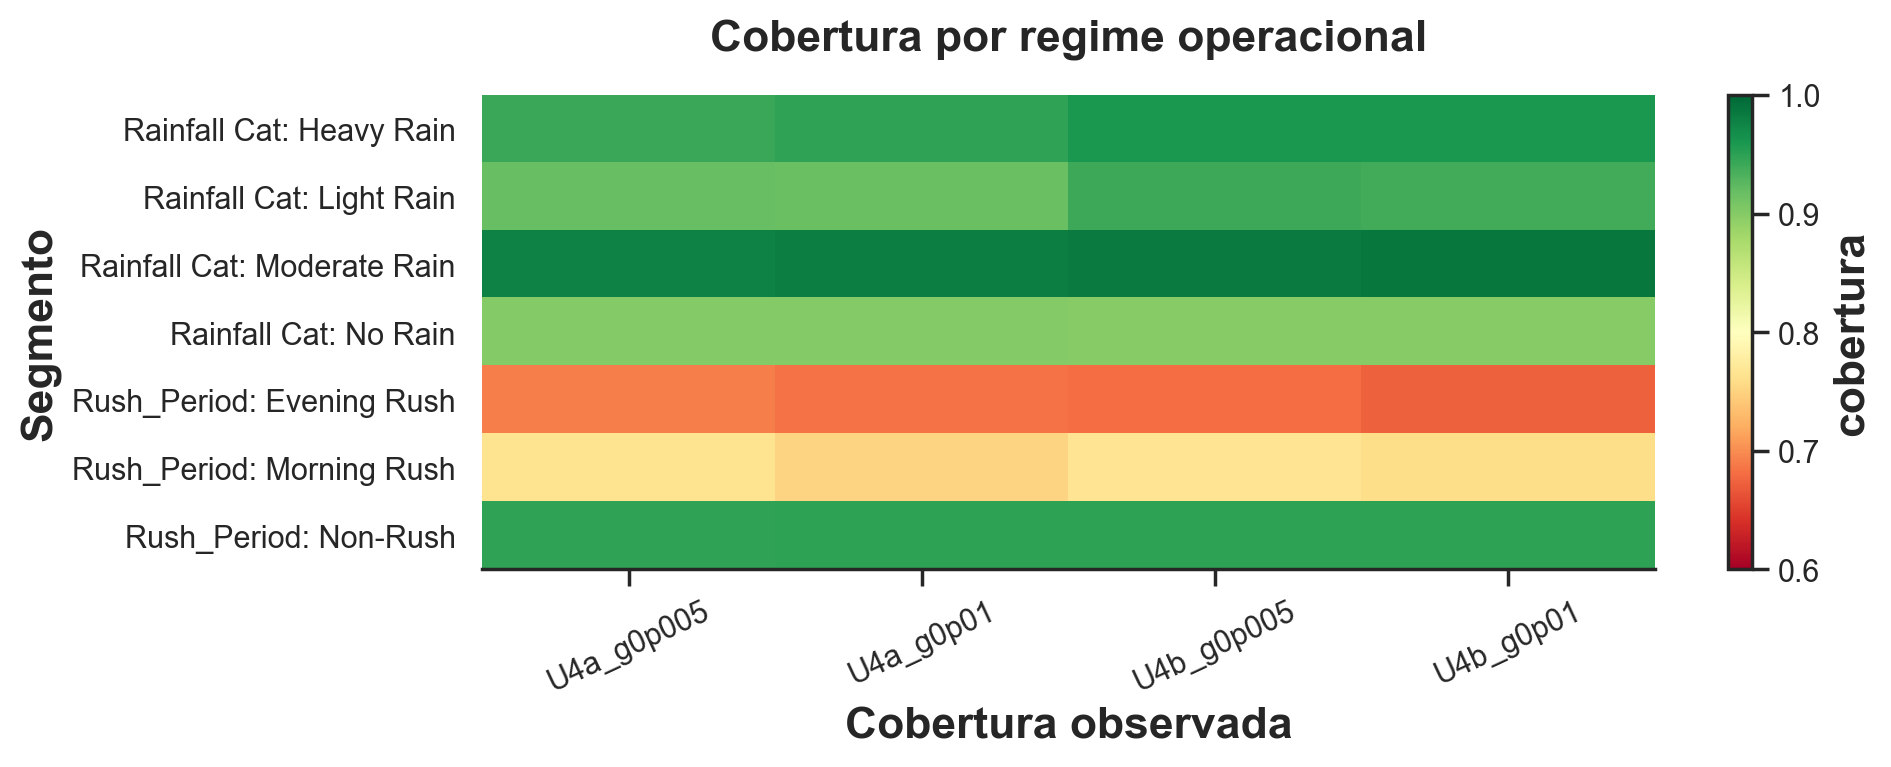

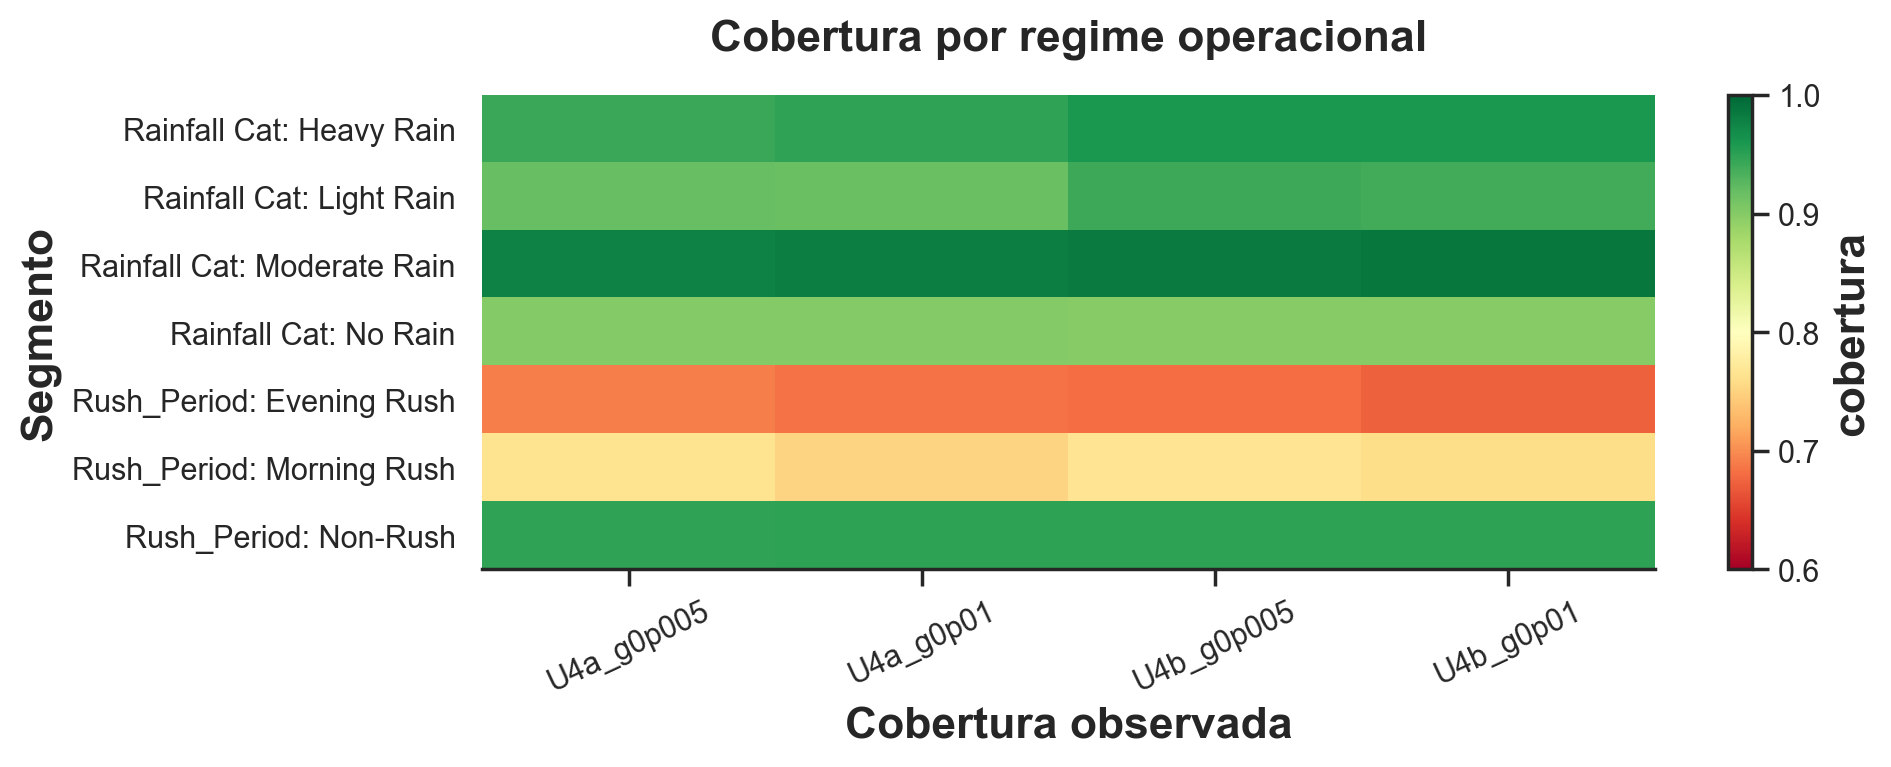

In [10]:
display(reports.segment_metrics_report(results, alerts_only=True, lang=lang))
reports.plot_segment_coverage(results, lang=lang)


## 13. Cobertura, sharpness e Winkler

As coberturas de 80%, 90% e 95% são avaliadas conjuntamente. Como uma densidade probabilística completa não foi construída, NLL não é calculada; cobertura, largura e Winkler score são mantidos como critérios próprios desta camada.


,Candidato,Método,Cobertura nominal,Folds calibrados,Cobertura observada,Erro de cobertura,Largura média,Winkler score,Violações inferiores,Violações superiores,Taxa de fallback
0,U5,U5,0.80,4,0.754362,-0.045638,1776.110804,3372.026416,0.097880,0.147758,0.177241
1,U1,U1,0.80,4,0.748286,-0.051714,1850.183201,3769.432889,0.099547,0.152167,0.000000
2,U4b_g0p01,U4b,0.80,4,0.803817,0.003817,2464.588824,3935.881643,0.070527,0.125656,0.000000
3,U4a_g0p01,U4a,0.80,4,0.804199,0.004199,2422.610448,3964.215719,0.068449,0.127352,0.000000
4,U4b_g0p005,U4b,0.80,4,0.804750,0.004750,2471.082843,3970.065540,0.069314,0.125936,0.000000
5,U4a_g0p005,U4a,0.80,4,0.804883,0.004883,2421.776515,3996.909770,0.067352,0.127765,0.000000
6,U2_h168,U2,0.80,4,0.792084,-0.007916,2346.188340,4029.057201,0.070197,0.137719,0.000000
7,U4b_g0p001,U4b,0.80,4,0.806029,0.006029,2531.673722,4048.253118,0.065526,0.128444,0.000000
8,U4a_g0p001,U4a,0.80,4,0.804832,0.004832,2476.438669,4073.327248,0.063664,0.131504,0.000000
9,U2_h720,U2,0.80,4,0.766517,-0.033483,2234.591700,4164.914078,0.076817,0.156666,0.000000


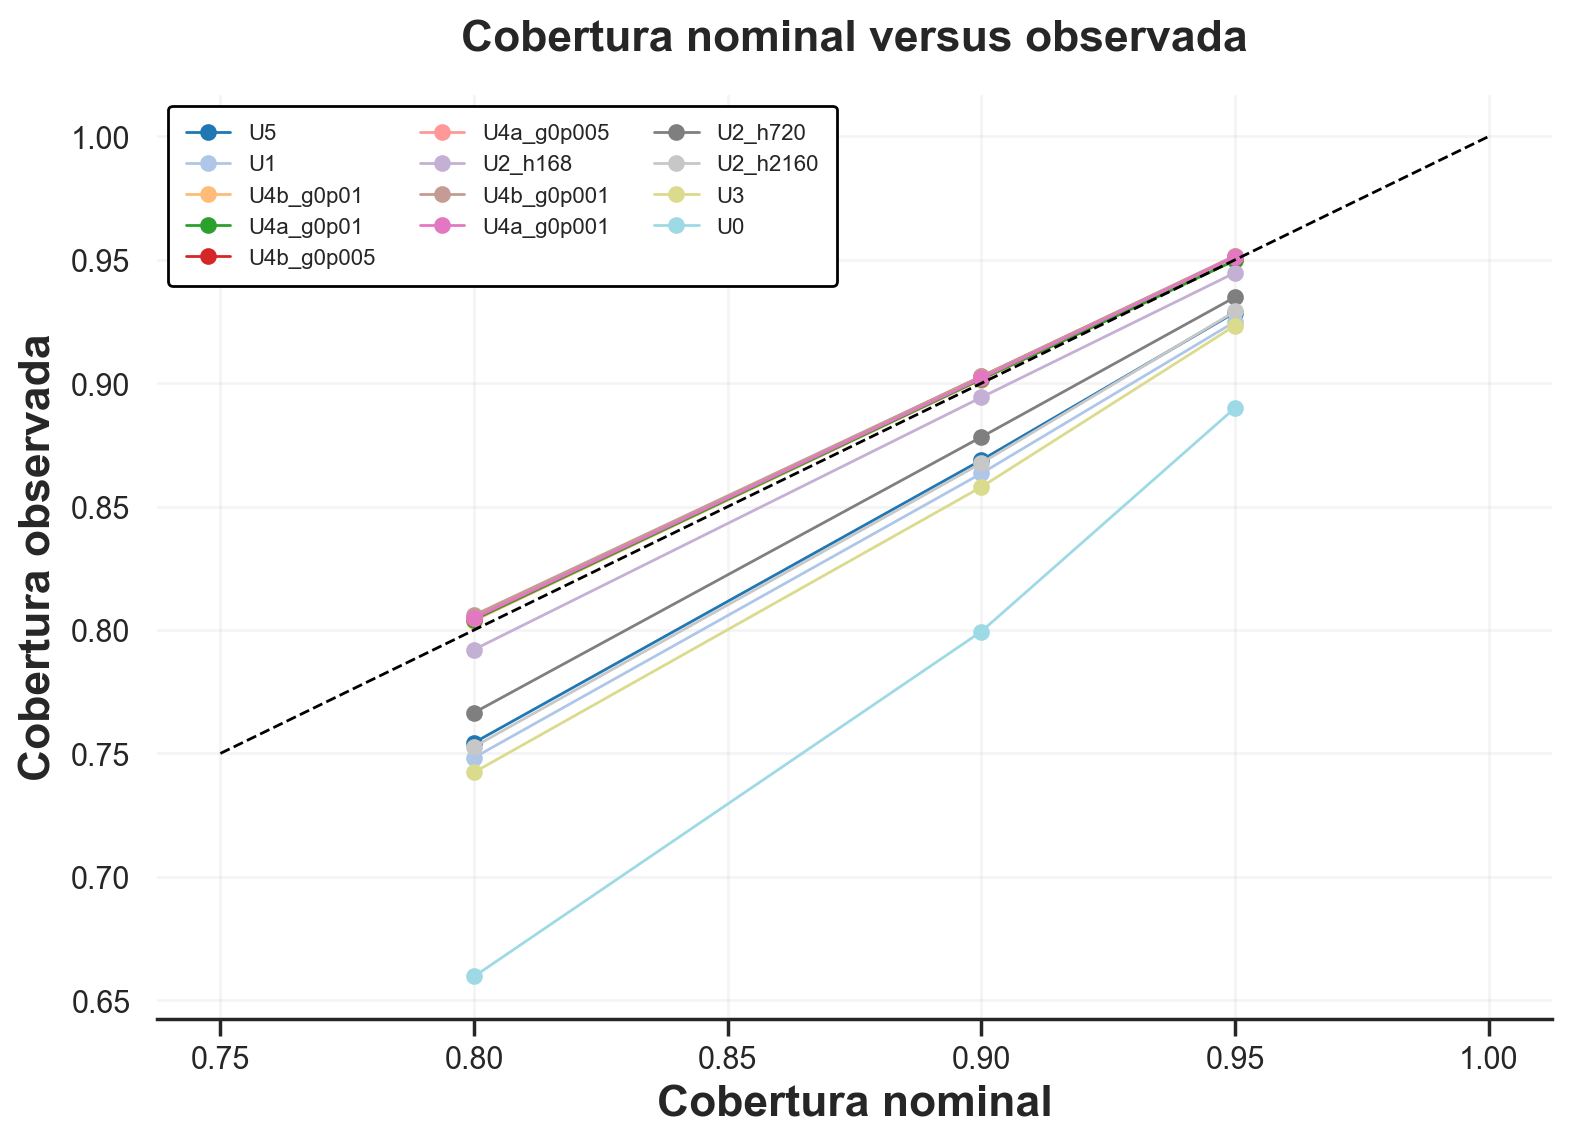

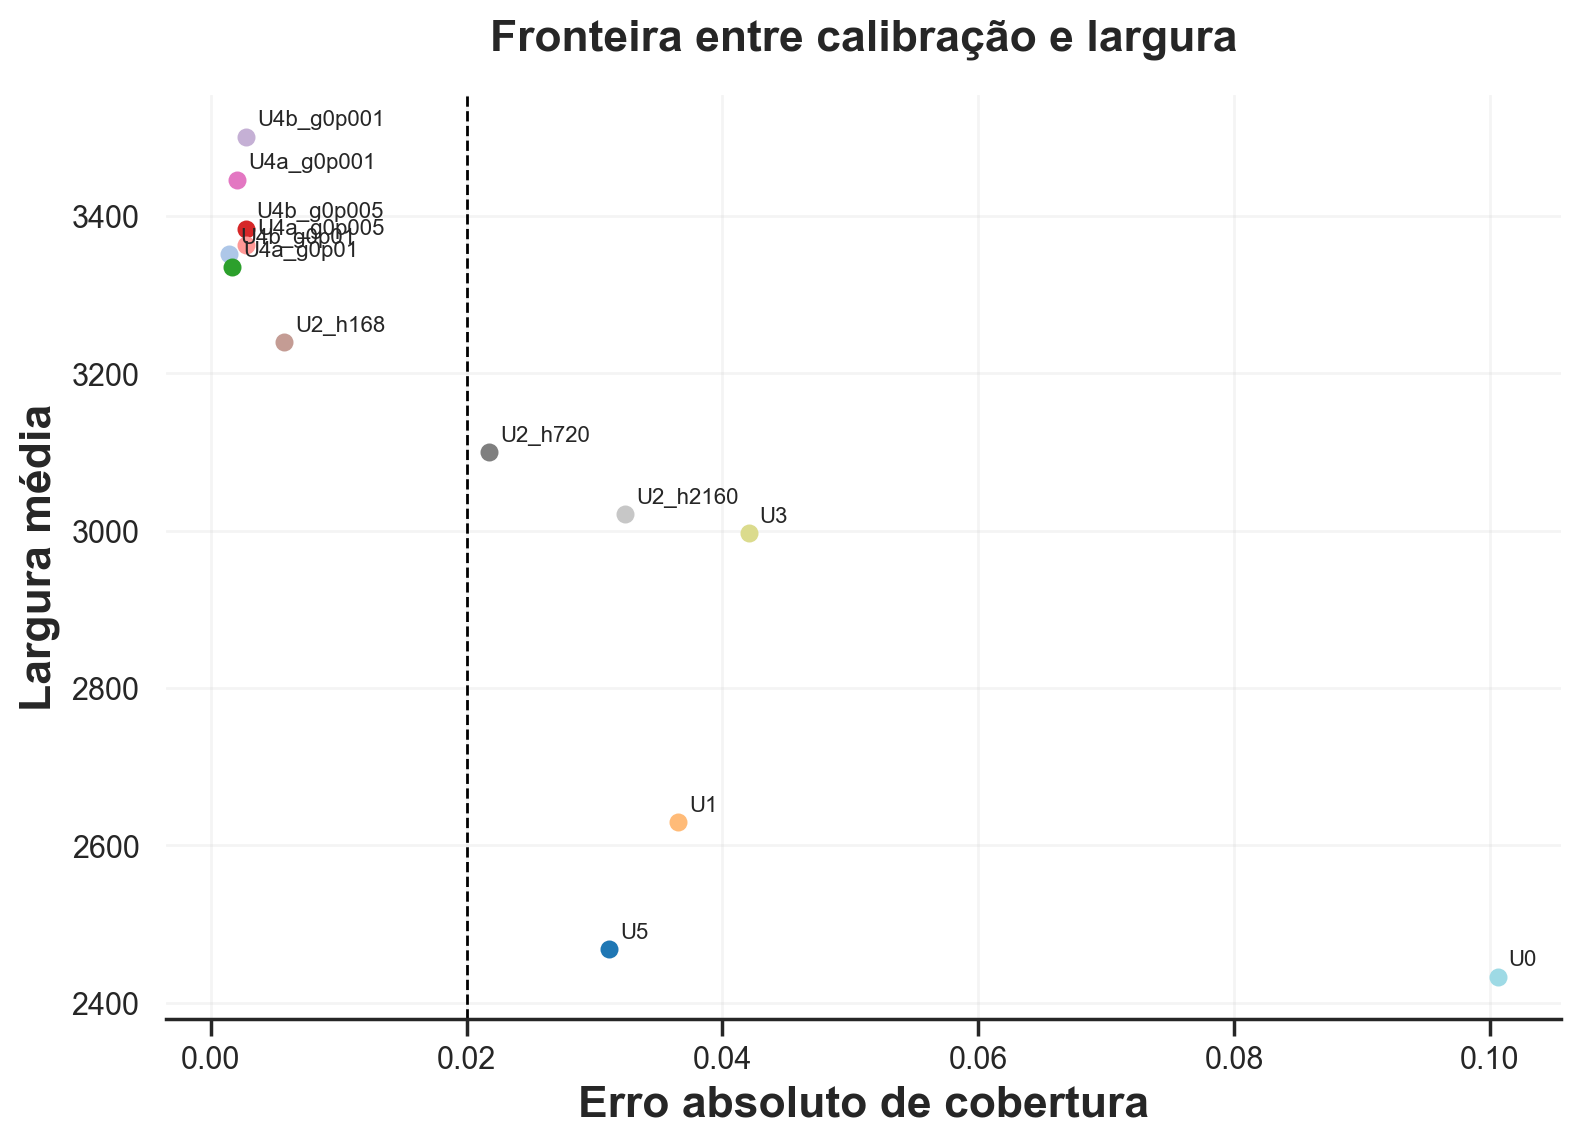

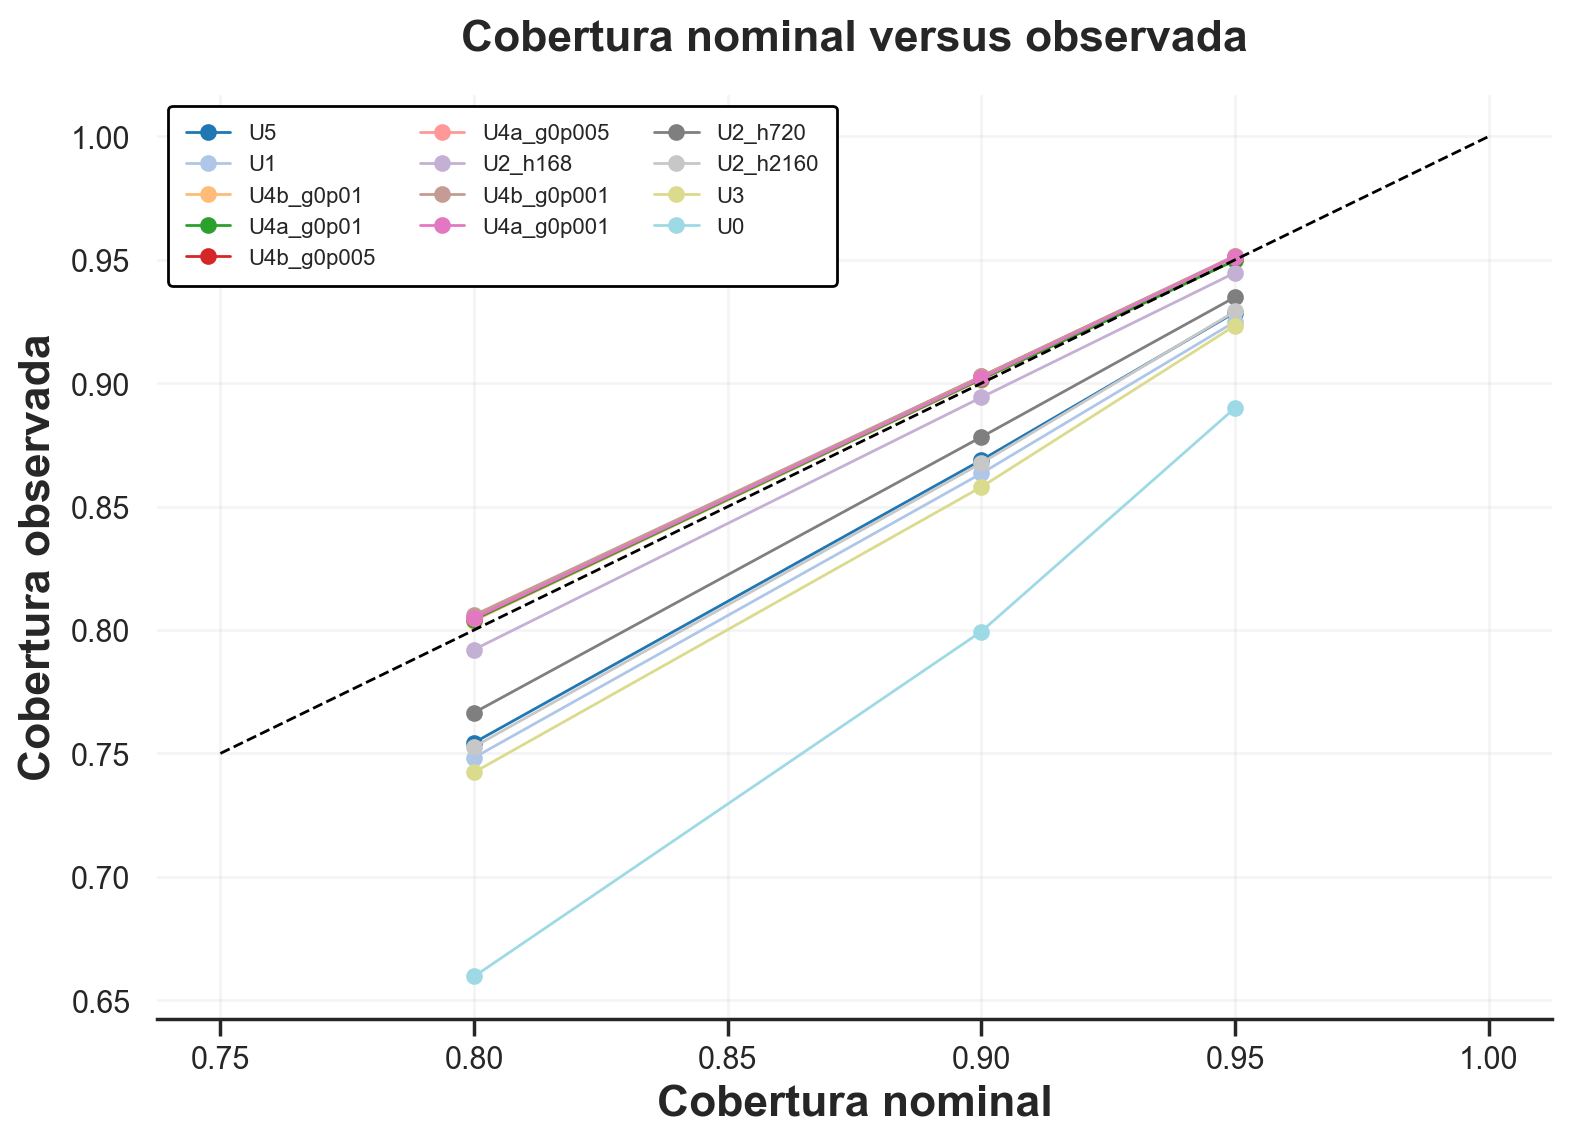

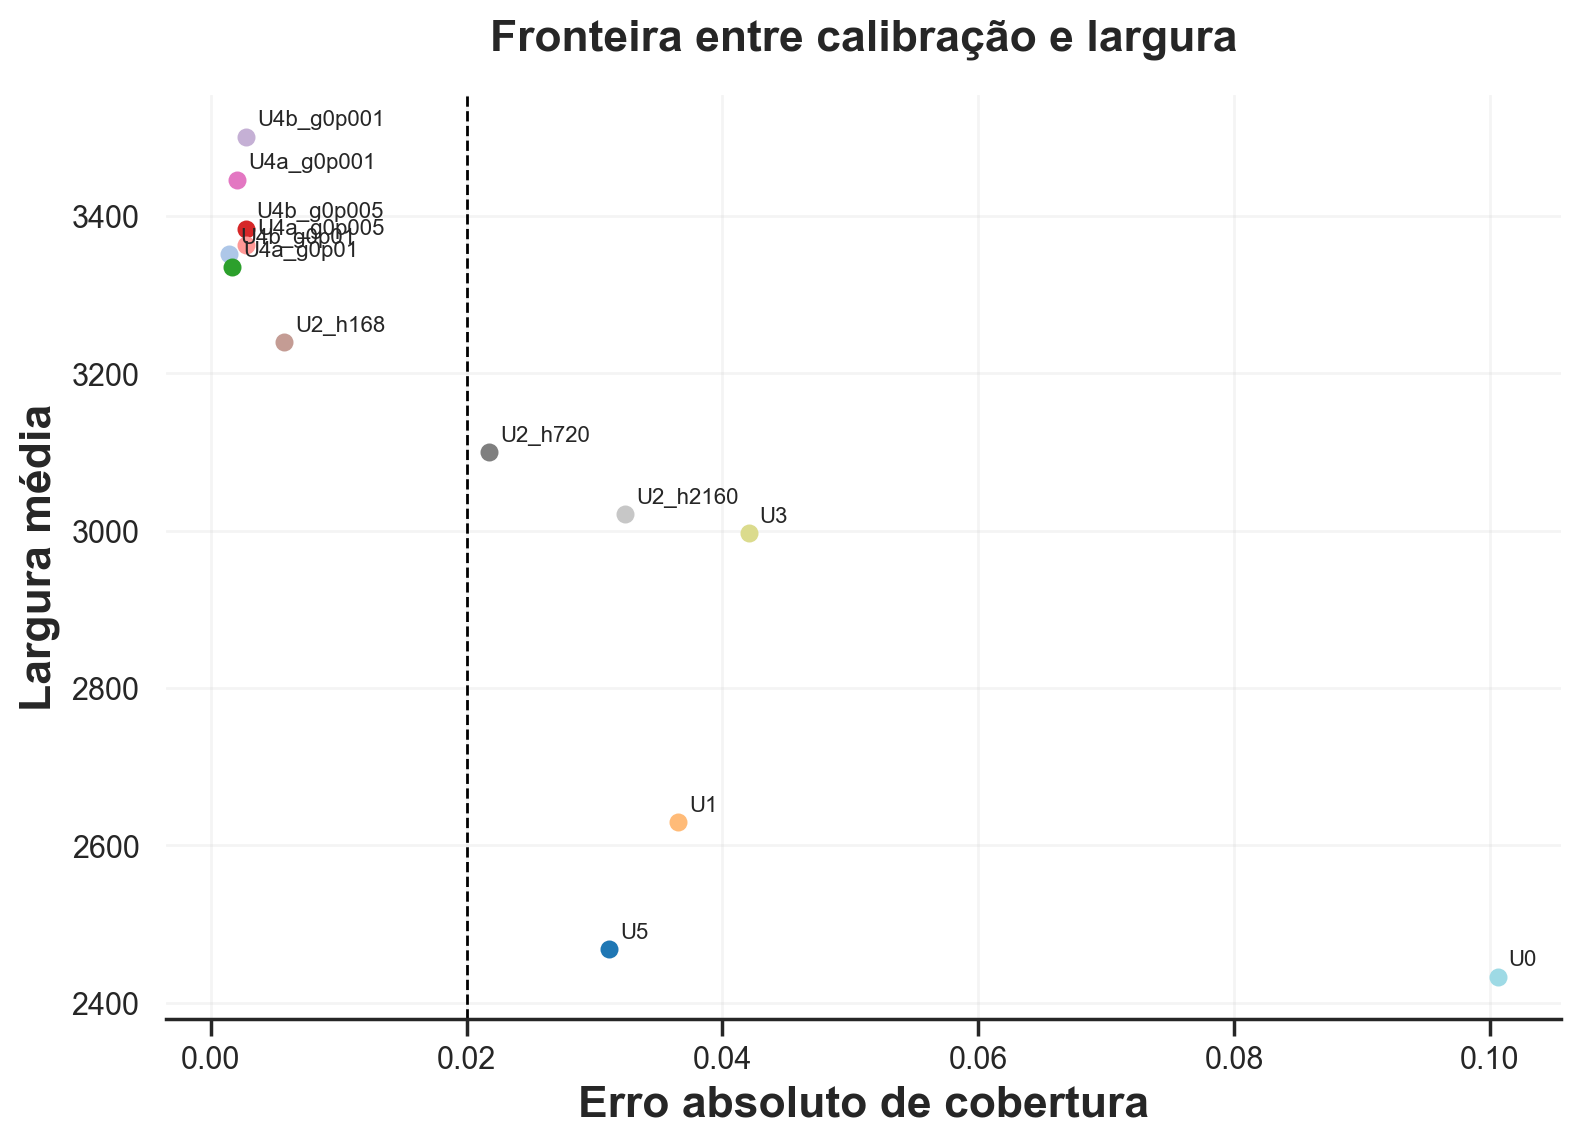

In [11]:
display(reports.aggregate_metrics_report(results, lang=lang))
display(reports.plot_coverage_calibration(results, lang=lang))
reports.plot_coverage_width_pareto(results, lang=lang)


## 14. Estabilidade por fold e no tempo

A cobertura é examinada por fold e em janelas móveis de 168 e 720 horas. Dessa forma, uma média agregada aparentemente adequada não oculta períodos prolongados de subcobertura.


,Candidato,Cobertura nominal,Fold,Ano meteorológico,Observações pontuadas,Cobertura observada,Erro de cobertura,Largura média,Winkler score,Taxa de fallback,Maior sequência descoberta
0,U0,0.80,1,2019,8547,0.593074,-0.206926,919.256664,2927.245779,0.000000,23
1,U0,0.90,1,2019,8547,0.764830,-0.135170,1366.623656,3662.869022,0.000000,20
2,U0,0.95,1,2019,8547,0.872821,-0.077179,1850.219562,4303.252912,0.000000,13
6,U0,0.80,3,2021,8592,0.756634,-0.043366,2328.483861,4259.117668,0.000000,18
7,U0,0.90,3,2021,8592,0.869646,-0.030354,3065.076996,5256.004796,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...
190,U5,0.90,4,2022,8591,0.863927,-0.036073,2599.043963,4583.858388,0.172506,15
191,U5,0.95,4,2022,8591,0.928297,-0.021703,3443.213435,5568.982857,0.172506,9
192,U5,0.80,5,2023,8592,0.760242,-0.039758,1844.239483,3627.048820,0.183077,19
193,U5,0.90,5,2023,8592,0.874069,-0.025931,2629.990400,4714.560877,0.183077,13


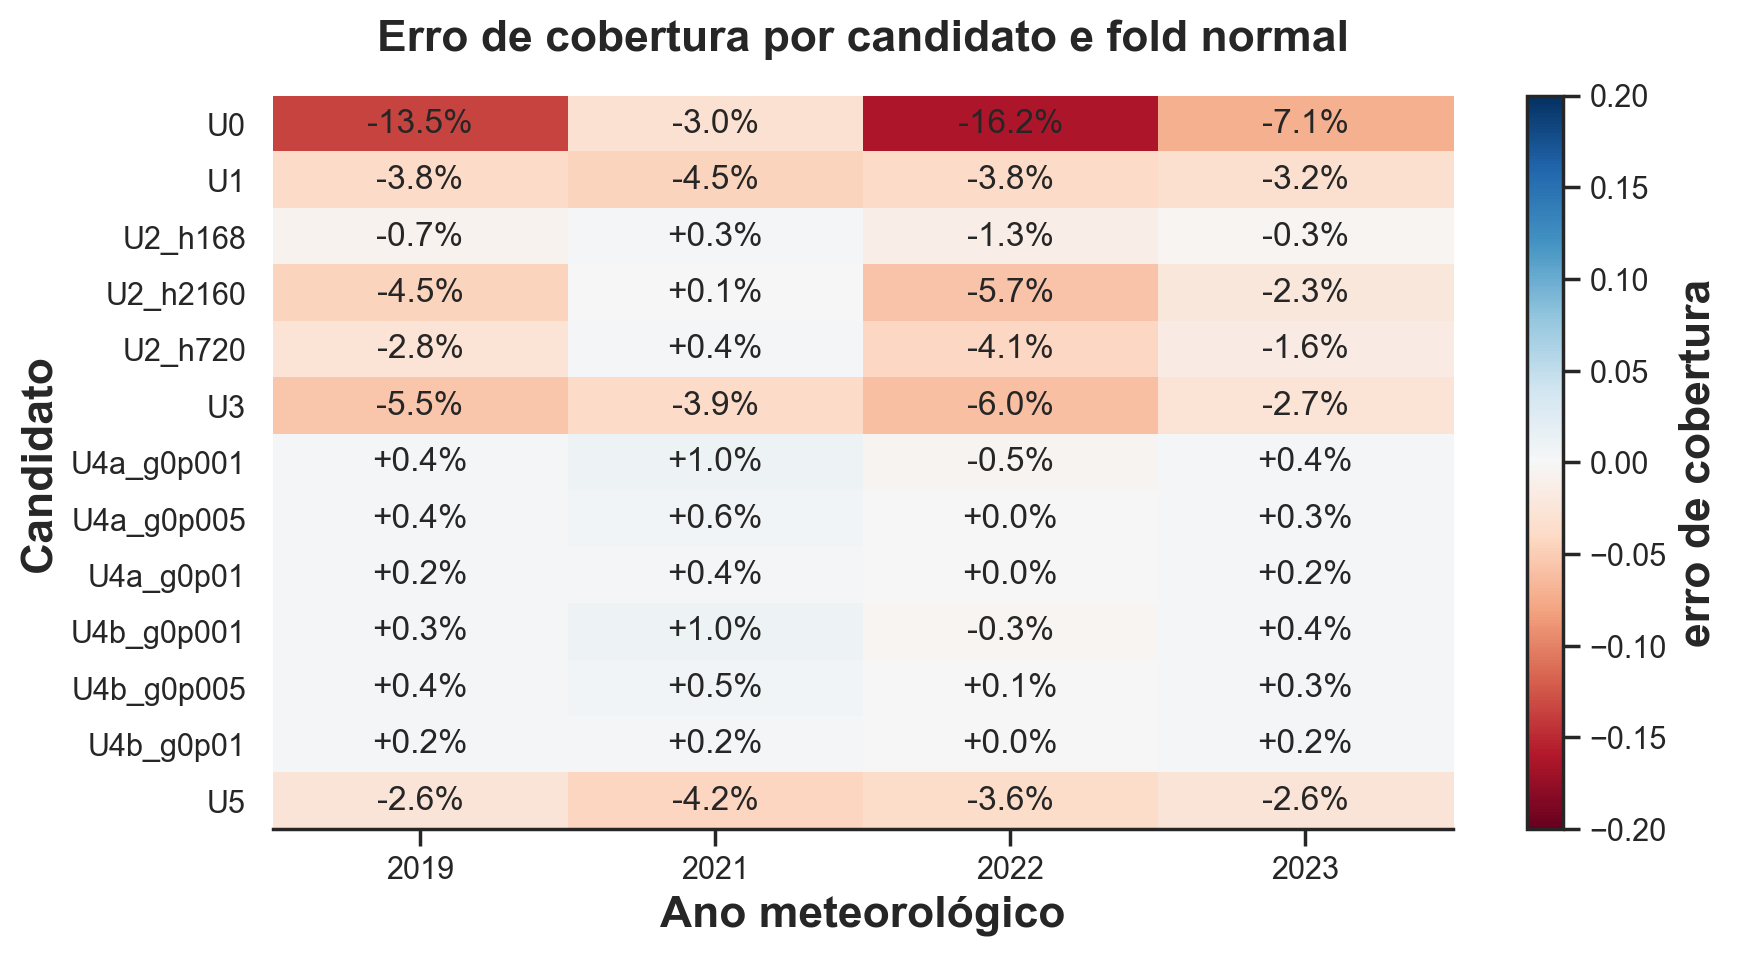

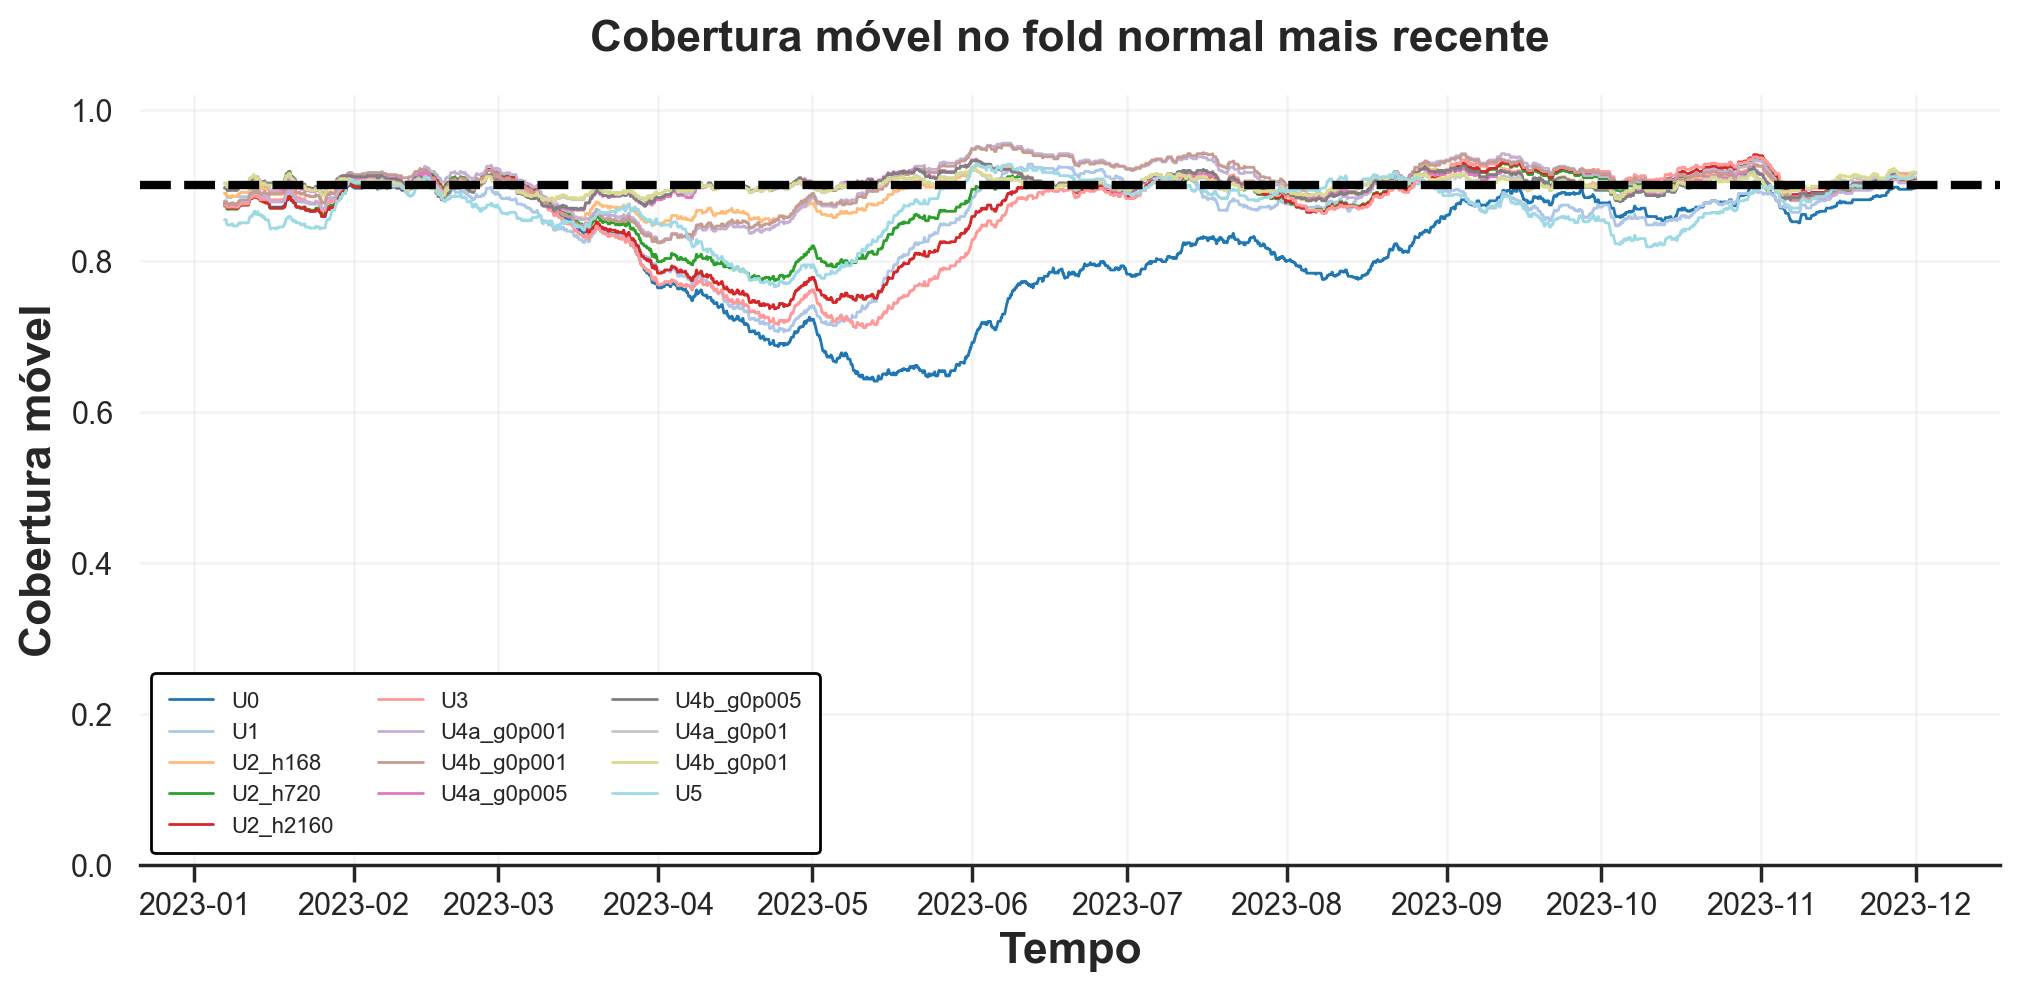

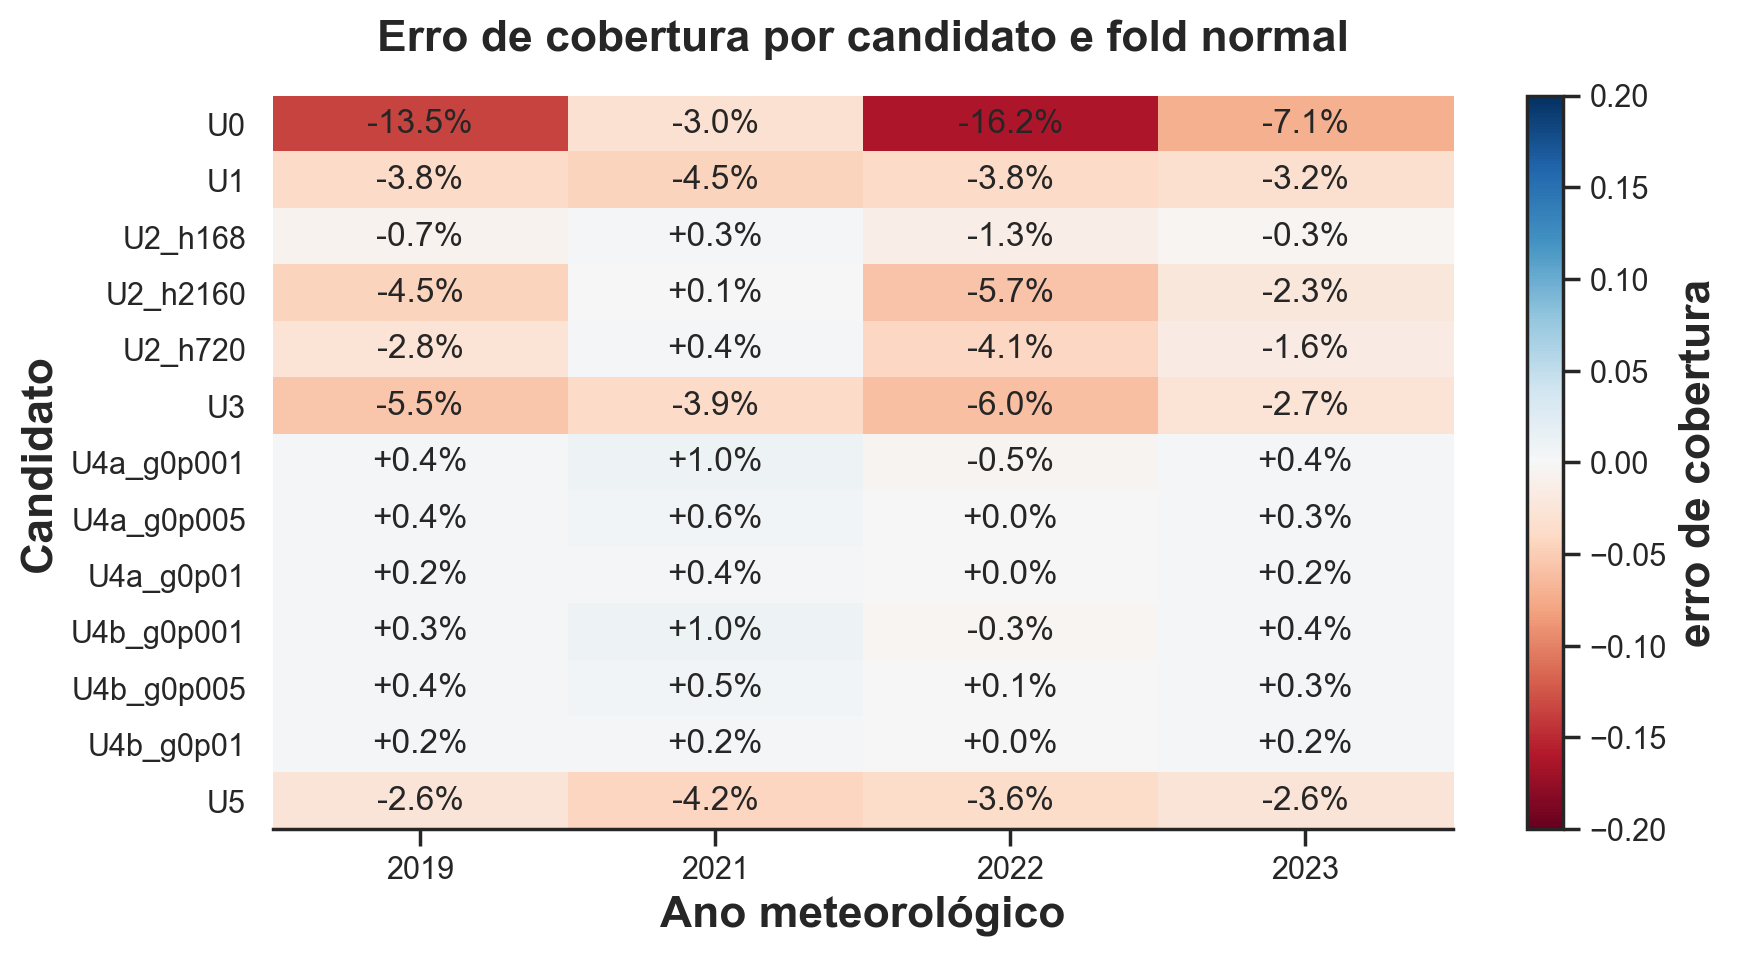

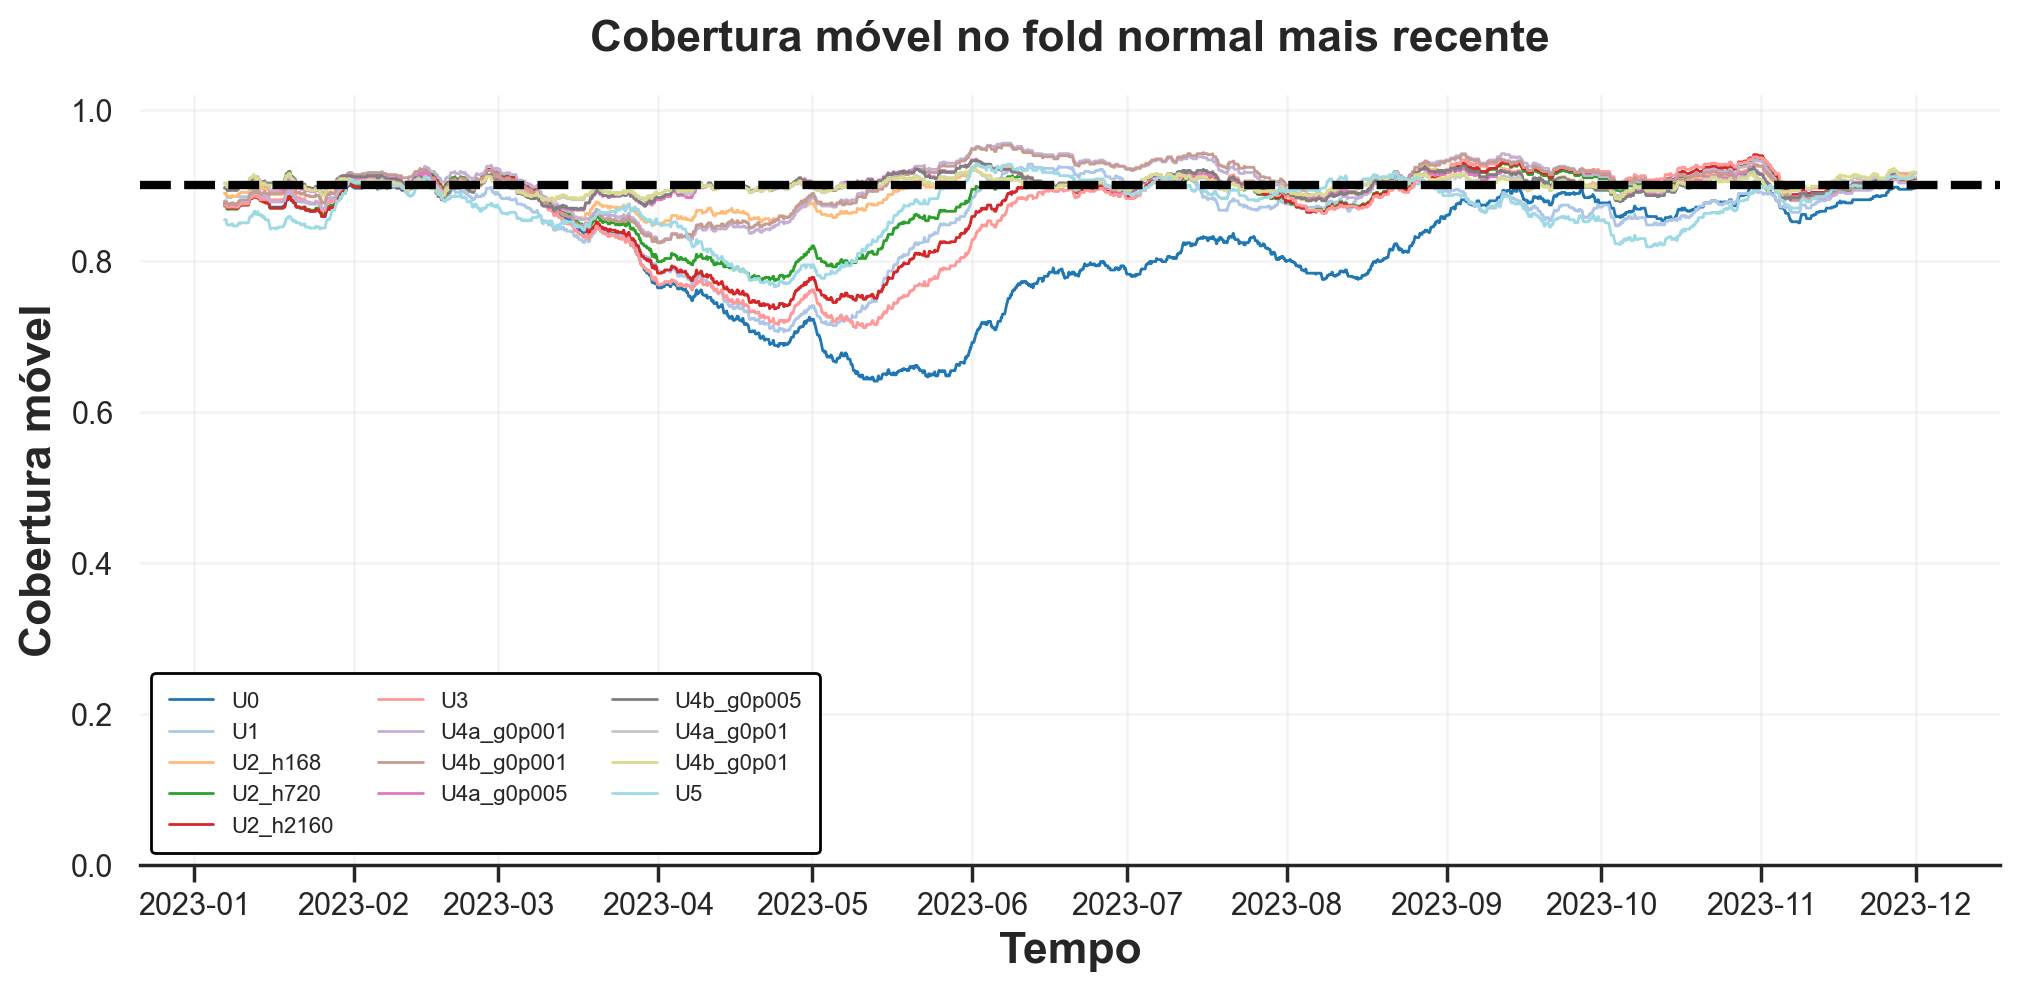

In [12]:
display(reports.fold_metrics_report(results, lang=lang))
display(reports.plot_fold_coverage_heatmap(results, lang=lang))
reports.plot_rolling_coverage(results, lang=lang)


## 15. Stress de 2020

O regime de 2020 é apresentado exclusivamente como stress. Seu estado é reiniciado, seus resultados ficam fora do ranking e nenhum resíduo desse período é transferido aos folds normais posteriores.


In [13]:
reports.stress_metrics_report(results, lang=lang)


,Candidato,Cobertura nominal,Ano de stress,Observações pontuadas,Cobertura de stress,Erro de cobertura,Largura média,Winkler score
3,U0,0.80,2020,8591,0.530672,-0.269328,2289.958551,8142.771539
4,U0,0.90,2020,8591,0.713770,-0.186230,3320.406146,9851.174818
5,U0,0.95,2020,8591,0.823653,-0.126347,4237.986528,11249.137396
18,U1,0.80,2020,8591,0.714934,-0.085066,1505.893920,3471.489681
19,U1,0.90,2020,8591,0.841811,-0.058189,1850.347639,4019.164266
20,U1,0.95,2020,8591,0.915027,-0.034973,2219.355506,4651.629240
33,U2_h168,0.80,2020,8591,0.777325,-0.022675,3839.073071,5784.429878
34,U2_h168,0.90,2020,8591,0.883948,-0.016052,4734.918038,6524.297689
35,U2_h168,0.95,2020,8591,0.941450,-0.008550,5397.596261,7336.241898
48,U2_h720,0.80,2020,8591,0.717728,-0.082272,3603.958630,6188.972931


## 16. Decisão experimental

O gate primário exige erro agregado de cobertura de até dois pontos percentuais e impede que o pior fold fique mais de cinco pontos abaixo do nominal. Entre candidatos viáveis, Winkler, largura, estabilidade e fallback são ordenados nessa sequência.

O bootstrap em blocos semanais é usado para expressar a incerteza da cobertura agregada sem atravessar folds.


,Candidato,Cobertura nominal,Cobertura observada,IC 95% inferior,IC 95% superior,Repetições,Tamanho do bloco (horas)
0,U0,0.9,0.799396,0.779503,0.816951,500,168
1,U1,0.9,0.863453,0.850075,0.873687,500,168
2,U2_h168,0.9,0.894270,0.887347,0.900429,500,168
3,U2_h720,0.9,0.878209,0.866195,0.887006,500,168
4,U2_h2160,0.9,0.867621,0.853955,0.877974,500,168
5,U3,0.9,0.857953,0.842922,0.869693,500,168
6,U4a_g0p001,0.9,0.902059,0.892213,0.908786,500,168
7,U4b_g0p001,0.9,0.902758,0.892014,0.910376,500,168
8,U4a_g0p005,0.9,0.902775,0.895461,0.907893,500,168
9,U4b_g0p005,0.9,0.902725,0.895913,0.907979,500,168


,Candidato,Método,Cobertura observada,Erro de cobertura,Pior cobertura por fold,Winkler score,Largura média,Desvio entre folds,Taxa de fallback,Alertas de segmento,Gate de cobertura,Ranking experimental
0,U4b_g0p01,U4b,0.901460,0.001460,0.900244,4836.901802,3351.031061,0.000822,0.000000,4,True,1.0
1,U4a_g0p01,U4a,0.901659,0.001659,0.900012,4895.725881,3334.975219,0.001547,0.000000,4,True,2.0
2,U4b_g0p005,U4b,0.902725,0.002725,0.900710,4901.799832,3383.733688,0.001496,0.000000,4,True,3.0
3,U4a_g0p005,U4a,0.902775,0.002775,0.900128,4956.182449,3363.234155,0.002050,0.000000,4,True,4.0
4,U4b_g0p001,U4b,0.902758,0.002758,0.896636,5021.338938,3500.802718,0.004711,0.000000,4,True,5.0
5,U2_h168,U2,0.894270,-0.005730,0.886742,5021.881360,3239.474294,0.006025,0.000000,4,True,6.0
6,U4a_g0p001,U4a,0.902059,0.002059,0.894657,5088.844671,3445.978002,0.005410,0.000000,4,True,7.0
7,U5,U5,0.868849,-0.031151,0.857542,4290.803280,2468.440523,0.007104,0.177241,3,False,NaN
8,U1,U1,0.863453,-0.036547,0.854749,4860.317600,2629.141214,0.004590,0.000000,5,False,NaN
9,U2_h720,U2,0.878209,-0.021791,0.859155,5240.044560,3099.351328,0.016624,0.000000,4,False,NaN


'O candidato U4b_g0p01 foi o calibrador experimental mais defensável: cobertura 90.1%, erro +0.15%, largura média 3,351.0 e Winkler score 4,836.9. A conclusão ainda exige uma nova janela independente antes de qualquer adoção operacional.'

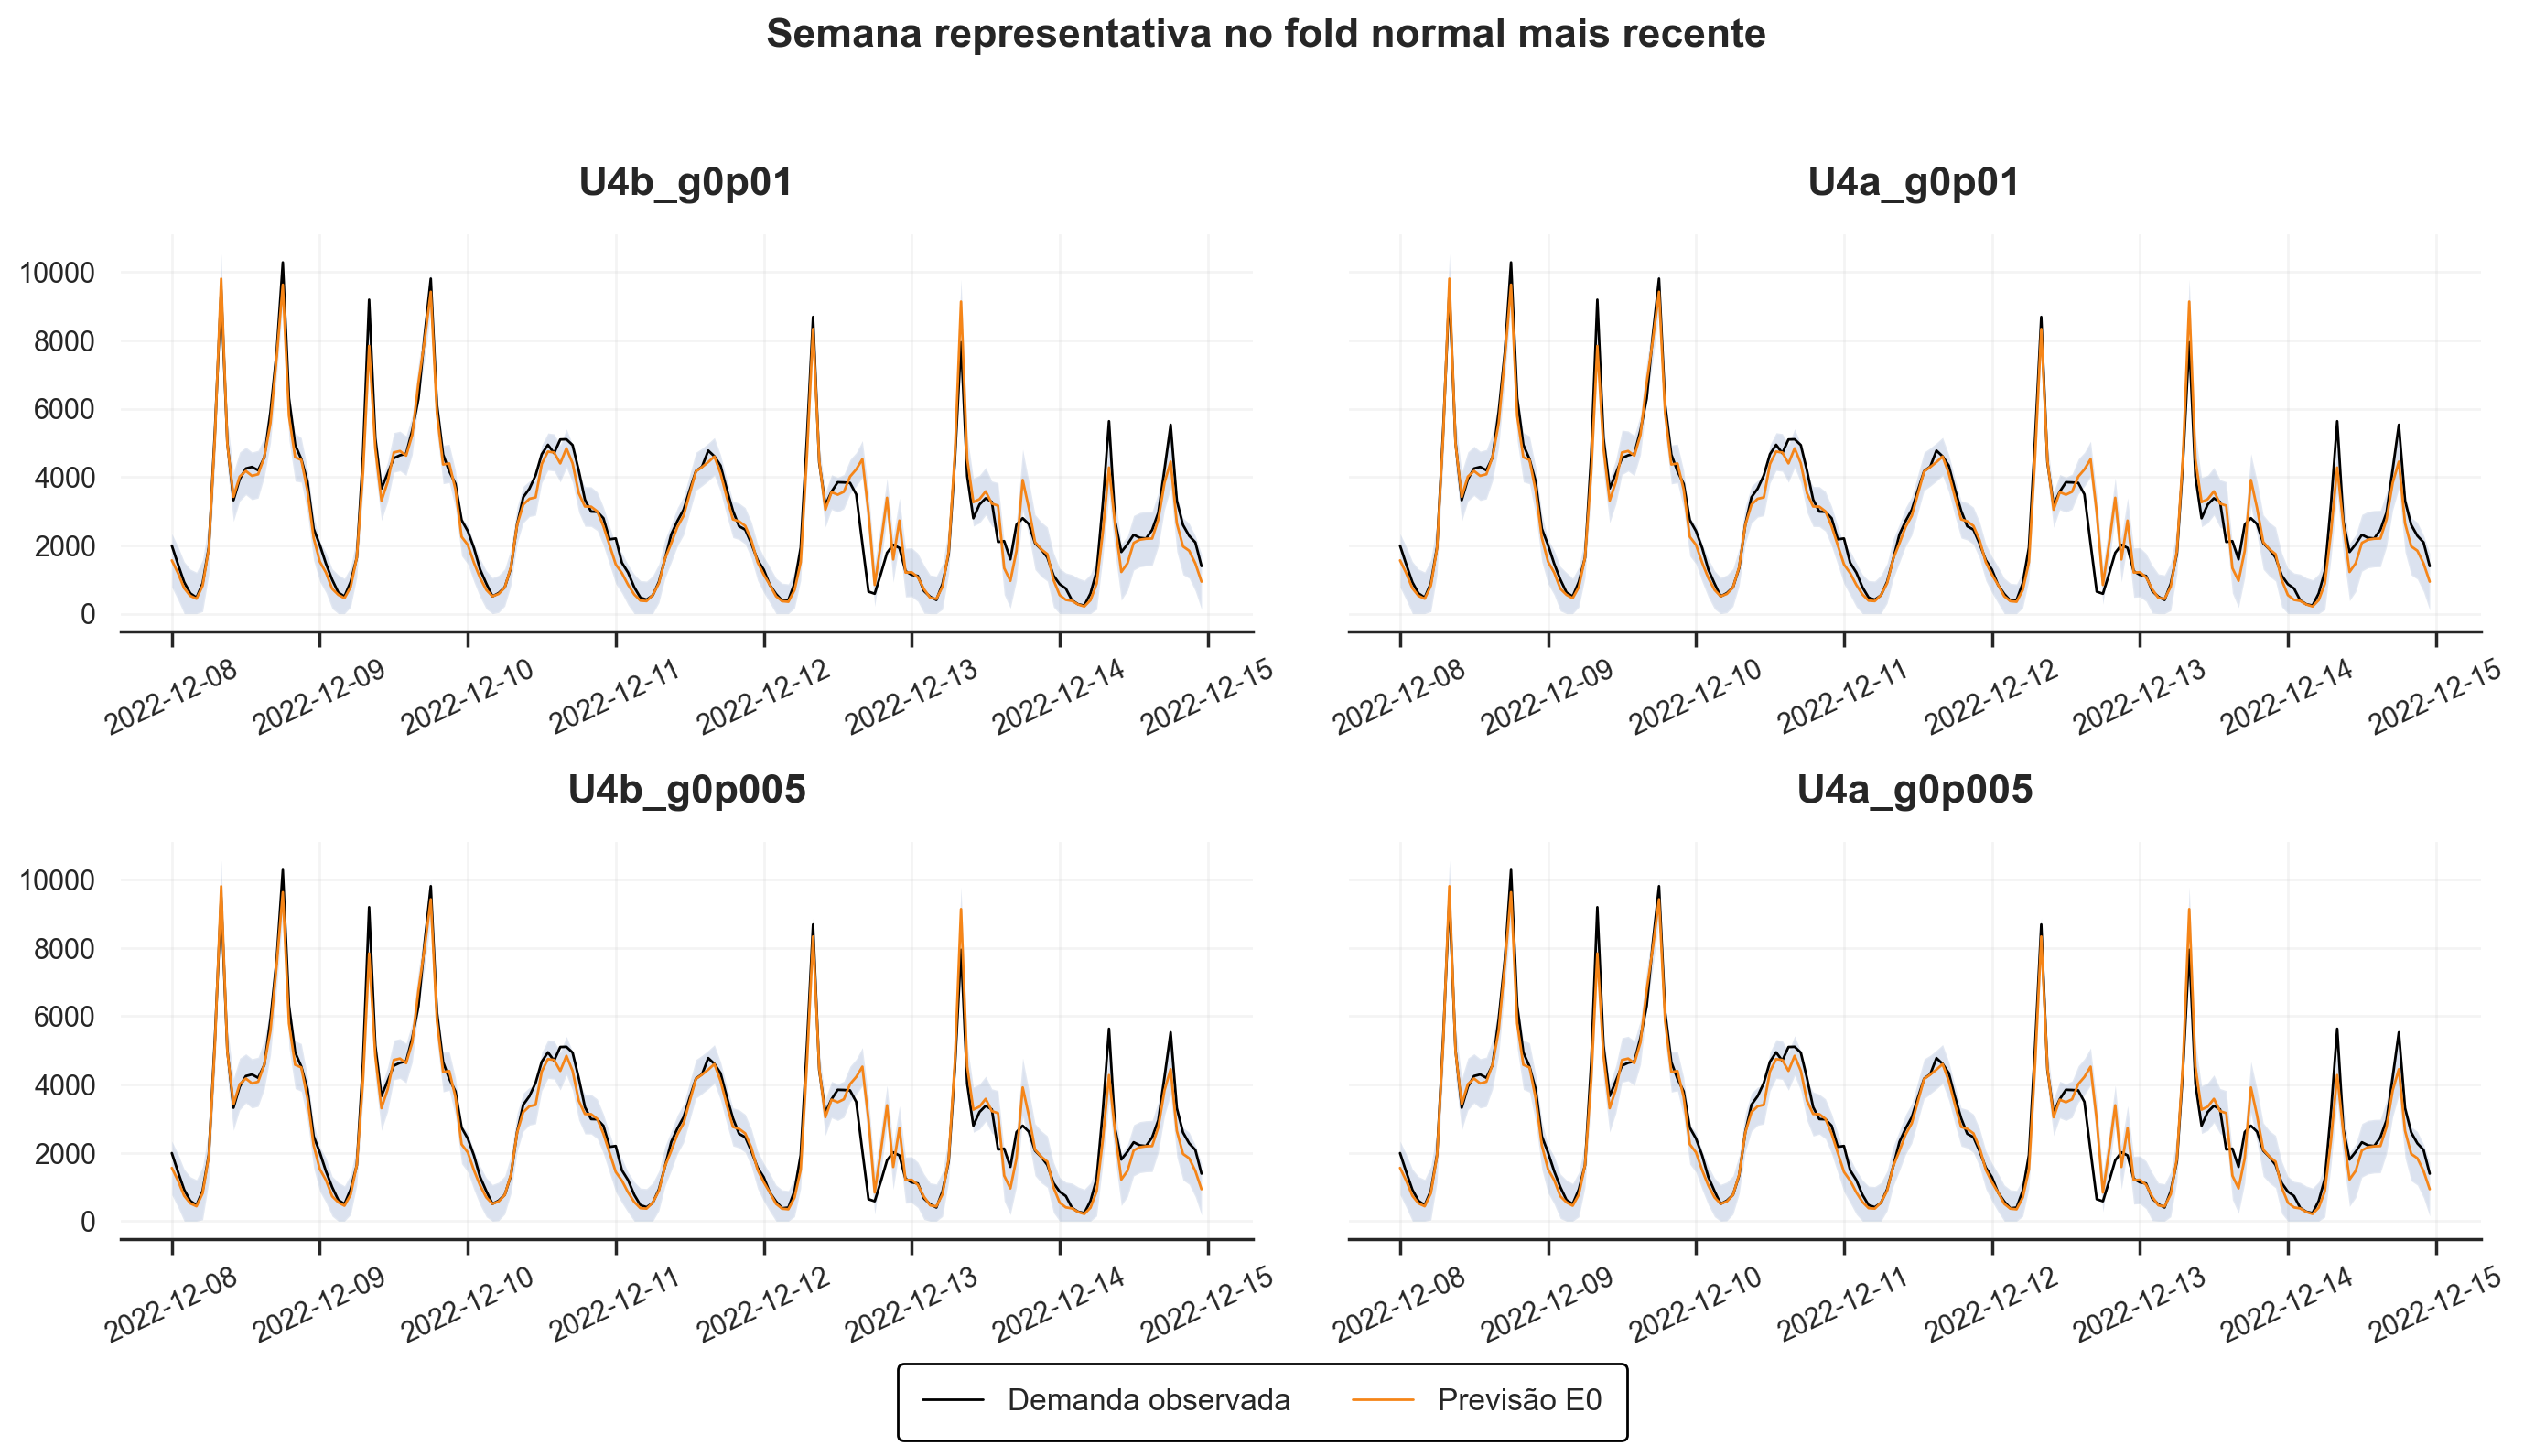

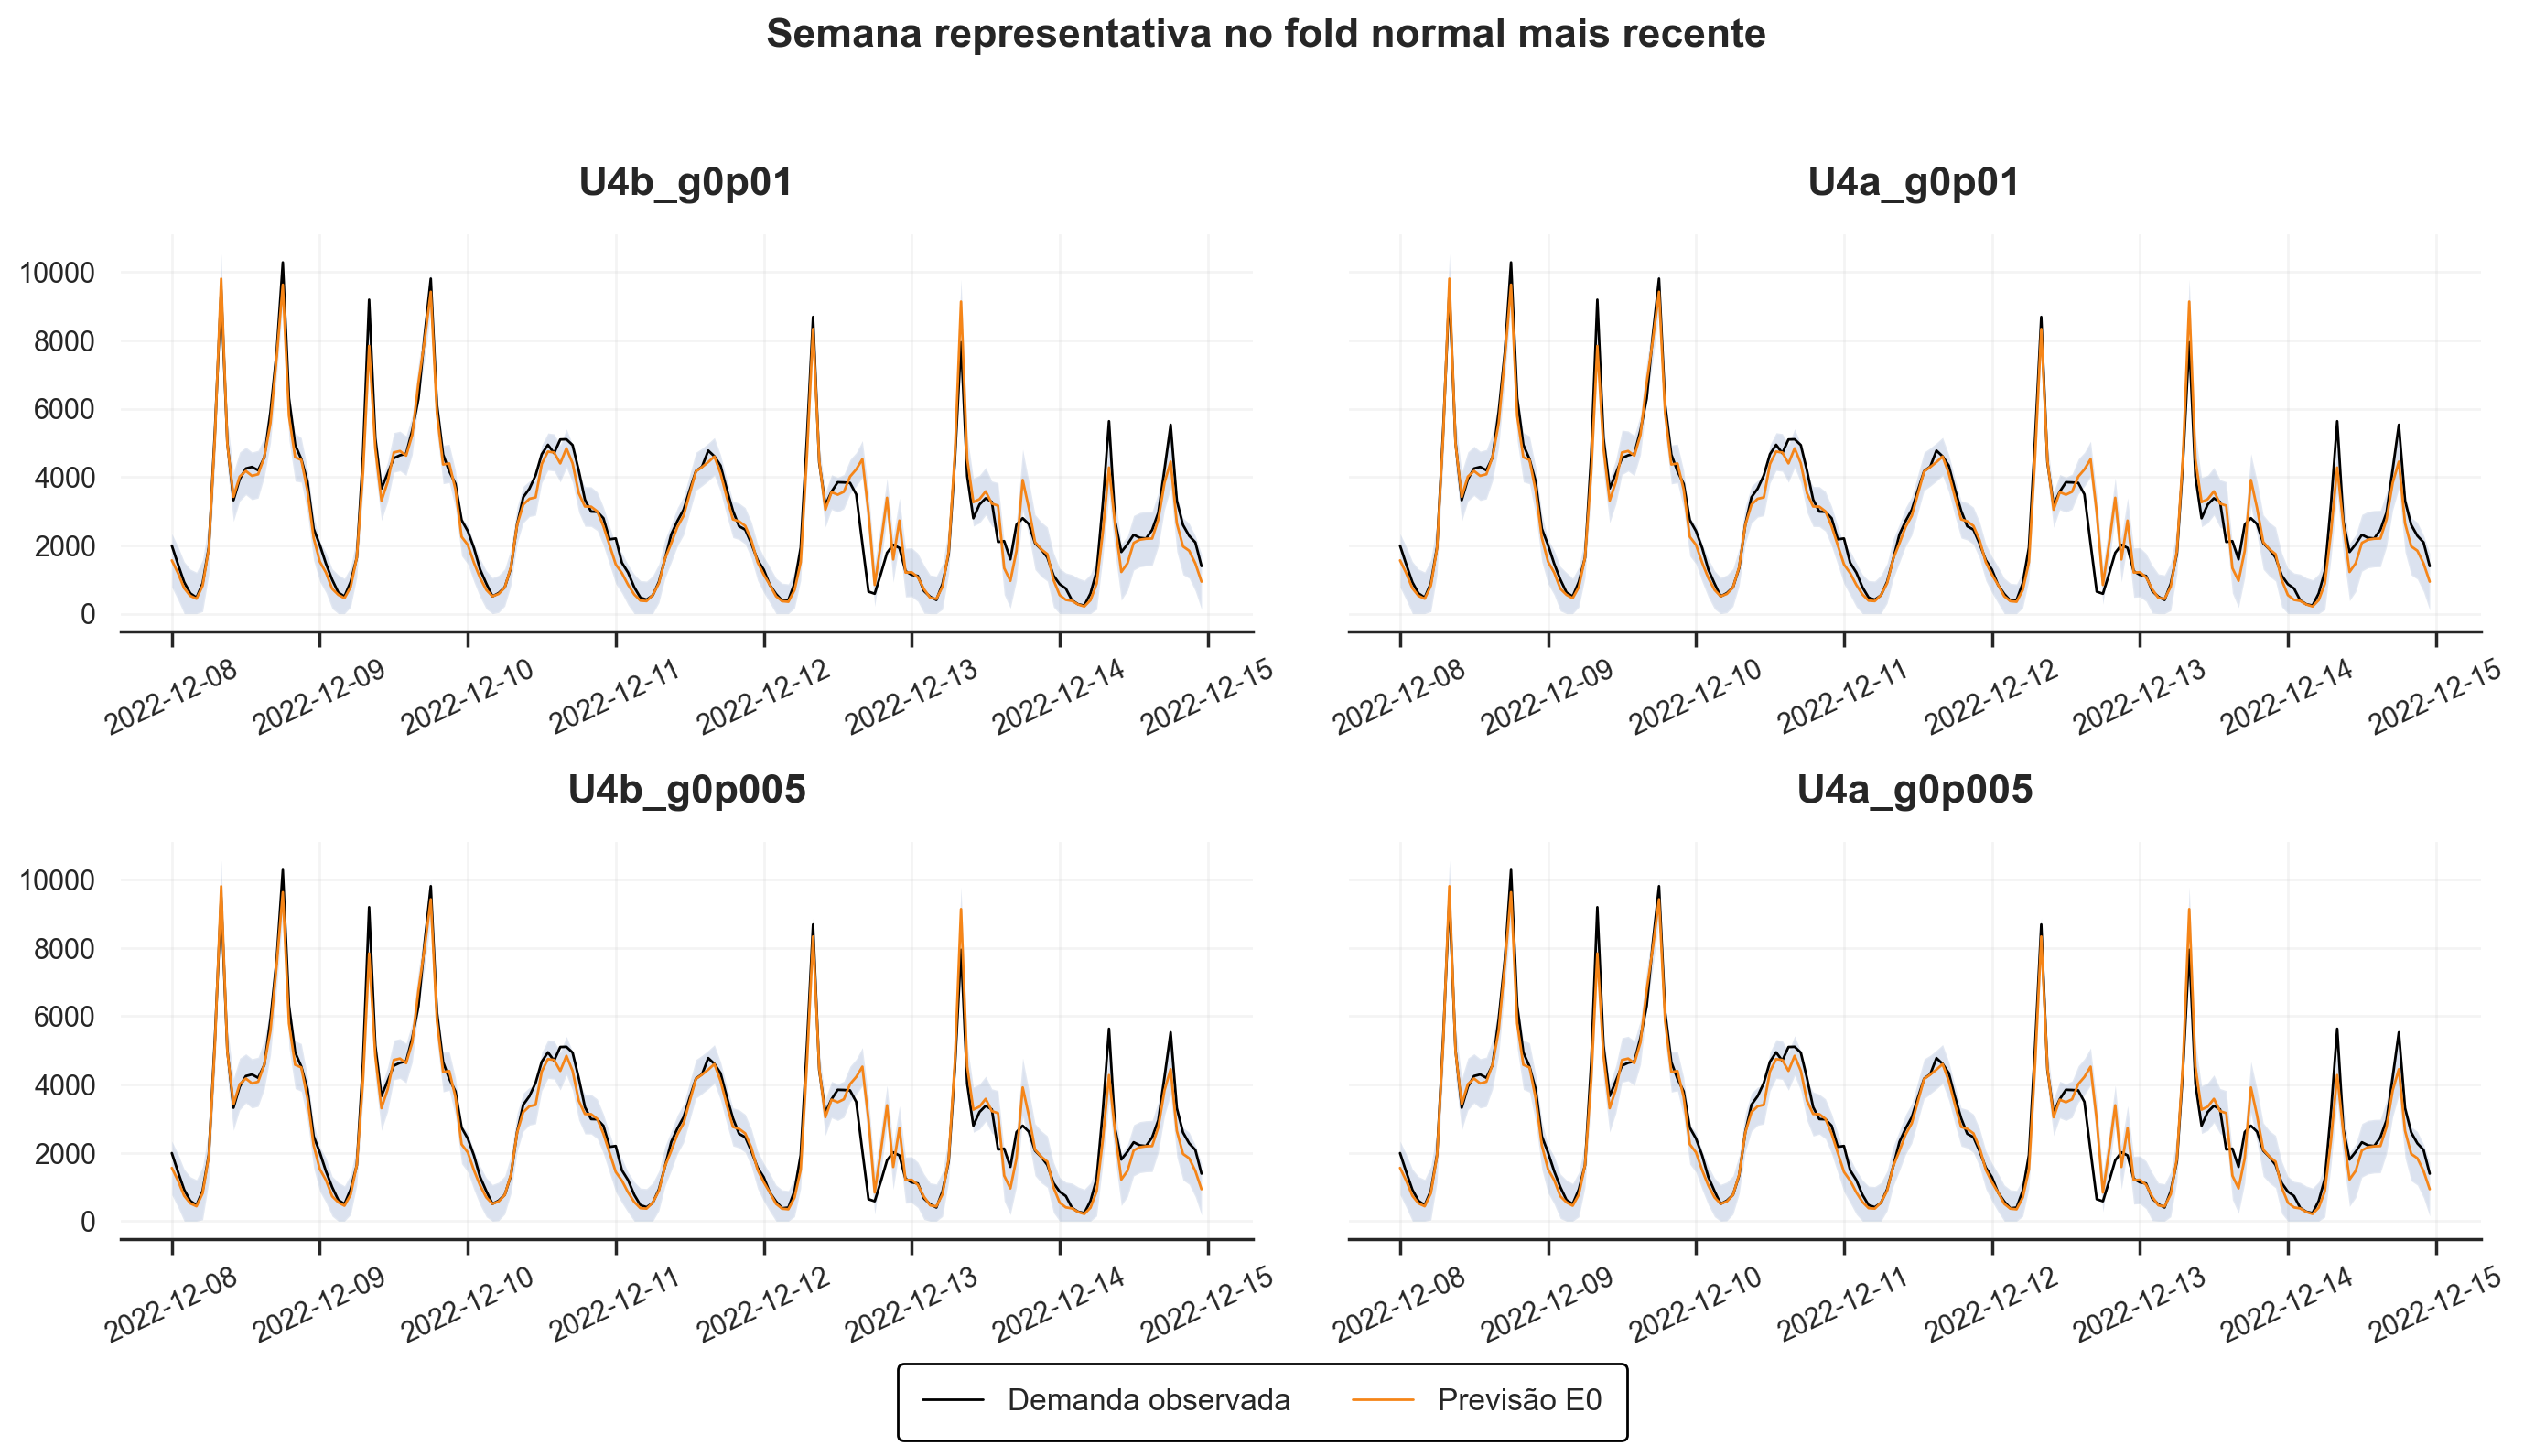

In [14]:
display(reports.bootstrap_report(results, lang=lang))
display(reports.decision_report(results, lang=lang))
display(reports.calibration_message(results, lang=lang))
reports.plot_representative_interval_windows(results, lang=lang)


### Insights

>Na execução `full`, foram pontuadas 34.322 observações dos quatro folds operacionais após o *warm-up* de 168 horas em cada janela. O U4b com `gamma=0,01` (`U4b_g0p01`) foi selecionado como o calibrador experimental mais defensável: para a cobertura nominal de 90%, foram obtidos 90,146% de cobertura, erro de apenas +0,146 ponto percentual, largura média de 3.351,0 bicicletas/hora e Winkler de 4.836,9. Entre os folds, a cobertura foi mantida entre 90,024% e 90,242%, com desvio-padrão de somente 0,082 ponto percentual. No *bootstrap* temporal de 500 repetições e blocos de 168 horas, foi estimado o intervalo de 89,709% a 90,591%, no qual a meta de 90% foi incluída.
>
>O ganho real do ajuste fino foi evidenciado pela comparação com o intervalo probabilístico E4 do Notebook 06. Na mesma cobertura nominal de 90%, o E4 havia alcançado 81,007% de cobertura, largura média de 4.501,5 e Winkler de 6.530,4. Com o `U4b_g0p01`, a cobertura foi elevada em 9,139 pontos percentuais, enquanto a distância absoluta até a meta foi reduzida de 8,993 para 0,146 ponto percentual, uma redução relativa de 98,4%. Simultaneamente, a largura média foi reduzida em 1.150,5 bicicletas/hora, ou 25,6%, e o Winkler foi reduzido em 1.693,5 pontos, ou 25,9%. Portanto, não foi comprada cobertura adicional por meio de intervalos artificialmente mais largos; foram obtidos, ao mesmo tempo, calibração e *sharpness* superiores.
>
>A adequação não ficou restrita ao nível primário: foram observadas coberturas de 80,382%, 90,146% e 94,983% para as metas de 80%, 90% e 95%, respectivamente. No regime de *stress* de 2020, mantido fora do ranking, também foram alcançados 90,222% para a meta de 90%. Esse resultado foi interpretado como evidência de adaptação prequential, e não como autorização para recolocar a pandemia no regime operacional normal.
>
>A calibração marginal ainda não foi reproduzida em todos os segmentos. Para 90% nominais, foram observadas coberturas de 67,276% no pico da tarde, 75,857% no pico da manhã, 75,055% na faixa de demanda muito alta e 44,828% às sextas-feiras às 18h. Assim, quatro alertas condicionais permaneceram ativos. A alternativa hierárquica U5 não resolveu essa fragilidade, pois foi limitada a 86,885% de cobertura agregada e exigiu *fallback* em 17,724% das observações.
>
>O `U4b_g0p01` foi aprovado apenas como candidato experimental para a camada de incerteza. O Champion pontual E0 foi preservado, suas previsões e métricas centrais não foram alteradas, nenhum estimator foi reajustado e o *holdout* selado não foi acessado. Antes de uma adoção operacional, ainda deverá ser demonstrada calibração condicional mais uniforme e realizada validação em uma nova janela independente.


## 17. Síntese

Neste notebook, a camada de incerteza do Champion E0 foi recalibrada sem que o modelo pontual fosse reajustado. Foram reutilizadas exclusivamente as previsões OOF congeladas no Notebook 06, e o contrato prequential foi preservado: em cada fold, as primeiras 168 horas foram reservadas para aquecimento, cada resíduo passou a ser utilizado somente depois de observado e o estado foi reinicializado antes da janela seguinte. O ano de 2020 foi processado como cenário de *stress*, mas foi excluído do ranking associado às condições operacionais normais.

Foram comparados calibradores expansíveis, assimétricos, ponderados por recência, normalizados pela escala E4, adaptativos e hierárquicos. A execução `full` mostrou que a adaptação observação a observação foi necessária: o baseline U0 alcançou apenas 79,940% para a meta de 90%, enquanto os candidatos U1, U3 e U5 também permaneceram subcalibrados. Entre as configurações que atravessaram o gate de cobertura, o `U4b_g0p01`, correspondente ao ACI normalizado pela escala E4 com `gamma=0,01`, recebeu o primeiro lugar experimental.

Para 90% nominais, foram obtidos pelo `U4b_g0p01` 90,146% de cobertura, largura média de 3.351,0 bicicletas/hora e Winkler de 4.836,9. A estabilidade temporal foi confirmada nos quatro folds de seleção, nos quais a cobertura variou somente de 90,024% a 90,242%. Também foi incluído o valor nominal de 90% no intervalo bootstrap de 95%, estimado entre 89,709% e 90,591%. Nas metas auxiliares, foram alcançados 80,382% para 80% e 94,983% para 95%, de modo que a adequação não foi produzida apenas por um ajuste isolado do nível primário.

Em relação ao E4 do Notebook 06, o ganho foi simultâneo em confiabilidade e eficiência. A cobertura de 90% foi elevada de 81,007% para 90,146%, um acréscimo de 9,139 pontos percentuais. A distância absoluta até a meta foi reduzida em 98,4%, de 8,993 para 0,146 ponto percentual. Ao mesmo tempo, a largura média foi reduzida de 4.501,5 para 3.351,0 bicicletas/hora, queda de 25,6%, e o Winkler foi reduzido de 6.530,4 para 4.836,9, queda de 25,9%. O ajuste fino, portanto, corrigiu a subcobertura sem inflar os intervalos. Como o centro E0 permaneceu congelado, esse ganho foi restrito à qualidade dos intervalos; MAE, RMSE e R² não foram modificados.

No cenário de *stress* de 2020, foram observados 90,222% de cobertura para a meta de 90%, o que demonstrou capacidade de adaptação mesmo sob mudança abrupta de regime. Ainda assim, essa janela não foi usada para promover o candidato nem para redefinir o escopo operacional do projeto.

A principal limitação foi localizada na cobertura condicional. Foram mantidos quatro alertas, concentrados nos picos da manhã e da tarde, na demanda muito alta e, sobretudo, às sextas-feiras às 18h, segmento em que a cobertura ficou em 44,828%. Por esse motivo, o `U4b_g0p01` foi caracterizado como candidato experimental da camada de incerteza, e não como componente pronto para produção. O próximo avanço deverá ser orientado à calibração por regimes de alta demanda, sem que seja perdida a estabilidade global obtida. O *holdout* permaneceu selado, nenhum sucessor pontual foi proposto e uma janela independente ainda será exigida antes de qualquer decisão operacional.


In [15]:
display(reports.artifact_report(results, lang=lang))
reports.synthesis_report(results, lang=lang)


,Artefato,Caminho
0,aci_alpha_trace,PROJECT_ROOT/...
1,aggregate_metrics,PROJECT_ROOT/...
2,bootstrap_metrics,PROJECT_ROOT/...
3,decision_table,PROJECT_ROOT/...
4,fold_metrics,PROJECT_ROOT/...
5,input_audit,PROJECT_ROOT/...
6,manifest,PROJECT_ROOT/...
7,method_specs,PROJECT_ROOT/...
8,predictions,PROJECT_ROOT/...
9,rolling_coverage,PROJECT_ROOT/...


'A execução full percorreu todos os folds declarados. O Champion pontual E0 foi preservado e somente os intervalos foram recalibrados. Em cada fold, as primeiras 168 horas foram tratadas como warm-up; a observação corrente atualizou apenas a previsão seguinte, e o estado foi reiniciado antes de cada nova janela temporal. O regime de 2020 foi mantido fora do ranking. A escala do E4 apresentou correlação de Spearman -0.135 com o erro absoluto do E0, o que quantifica sua utilidade de ordenação sem pressupor calibração. O candidato U4b_g0p01 foi o calibrador experimental mais defensável: cobertura 90.1%, erro +0.15%, largura média 3,351.0 e Winkler score 4,836.9. A conclusão ainda exige uma nova janela independente antes de qualquer adoção operacional. O holdout selado não foi reaberto, nenhum estimator foi reajustado e nenhum sucessor pontual foi proposto.'

### Referência metodológica

Gibbs, I.; Candès, E. J. (2021). Adaptive Conformal Inference Under Distribution Shift. Advances in Neural Information Processing Systems, 34, 1660–1672.

Barber, R. F.; Candès, E. J.; Ramdas, A.; Tibshirani, R. J. (2023). Conformal Prediction Beyond Exchangeability. The Annals of Statistics, 51(2), 816–845.

Romano, Y.; Patterson, E.; Candès, E. J. (2019). Conformalized Quantile Regression. Advances in Neural Information Processing Systems, 32.

Gneiting, T.; Raftery, A. E. (2007). Strictly Proper Scoring Rules, Prediction, and Estimation. Journal of the American Statistical Association, 102(477), 359–378.
